# Proyecto Final: Clasificacion de Casco de Seguridad con CNN

## Aprendizaje Profundo — Maestria USFQ — 2026

**Objetivo:** Entrenar un clasificador binario (con casco / sin casco) usando Transfer Learning
con ResNet18 como baseline para la tesis de deteccion de EPP en obras de construccion.

| Item | Detalle |
|------|---------|
| **Tecnica del curso** | CNNs con Transfer Learning (Taller 01) |
| **Dataset** | Construction Site Safety Image Dataset (Kaggle) — dataset de la tesis |
| **Framework** | PyTorch + PyTorch Lightning |
| **Modelo** | ResNet18 pre-entrenada en ImageNet |

## Tabla de Contenidos

1. Configuracion e Importaciones
2. Hiperparametros
3. Descarga y Exploracion del Dataset
4. Conversion YOLO a Clasificacion
5. Analisis del Dataset Generado
6. Division Train / Validation / Test
7. Data Augmentation y Transforms
8. Definicion del Modelo
9. Entrenamiento Base (V1)
10. Analisis de Curvas de Entrenamiento (V1)
11. Ajuste de Hiperparametros y Re-entrenamiento (V2)
12. Evaluacion Final
13. Conclusiones

---
## 1. Configuracion e Importaciones

In [1]:
# Instalar dependencias
# pip install lightning torchmetrics kagglehub

In [2]:
import os
import glob
import shutil
import random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18, ResNet18_Weights

import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers import CSVLogger

import torchmetrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

c:\Users\Administrador\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Reproducibilidad
SEED = 42
L.seed_everything(SEED, workers=True)
torch.set_float32_matmul_precision('medium')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Seed set to 42


Dispositivo: cuda
GPU: NVIDIA GeForce RTX 4080 SUPER


---
## 2. Hiperparametros

Se seleccionan los mejores hiperparametros iniciales para fine-tuning de ResNet18
en este problema, basados en la literatura y en la experiencia del Taller 01 del curso.

Tras el entrenamiento base (V1), se analizaran las curvas y se realizara un segundo
entrenamiento (V2) con ajustes basados en el diagnostico.

In [4]:
# ─── Hiperparametros V1 (mejor configuracion inicial) ────────────
BATCH_SIZE    = 32       # Estandar para clasificacion de imagenes; funciona bien en GPU
LEARNING_RATE = 3e-4     # Rango recomendado para fine-tuning (1e-4 a 5e-4); 1e-3 es
                         # demasiado agresivo y destruye features de ImageNet
NUM_EPOCHS    = 30       # Techo generoso; early stopping detiene antes si es necesario
DROPOUT       = 0.2      # Regularizacion ligera desde el inicio: ~3300 muestras de
                         # entrenamiento para 11.2M parametros justifica algo de dropout
PATIENCE      = 5        # Mas margen que 3 para encontrar un buen minimo antes de detener
NUM_CLASSES   = 2        # Binario: con_casco / sin_casco
IMAGE_SIZE    = 224      # Tamano estandar de entrada para ResNet18 (pesos ImageNet)
NUM_WORKERS   = 0        # 0 para compatibilidad con Windows
PADDING_RATIO = 0.15     # Padding al recortar bounding boxes (15% extra de contexto)
MIN_CROP_SIZE = 20       # Tamano minimo de crop en pixeles (descartar muy pequenos)

# Clases del dataset YOLO que usaremos
TARGET_CLASSES = {0: 'con_casco', 2: 'sin_casco'}
CLASS_NAMES = ['con_casco', 'sin_casco']

# Directorios de salida
CROPS_DIR = 'crops'
LOG_DIR   = 'logs'
RUN_NAME  = 'resnet18-helmet-v1'

print('Hiperparametros V1 definidos:')
print(f'  LEARNING_RATE = {LEARNING_RATE}')
print(f'  DROPOUT       = {DROPOUT}')
print(f'  BATCH_SIZE    = {BATCH_SIZE}')
print(f'  PATIENCE      = {PATIENCE}')
print(f'  NUM_EPOCHS    = {NUM_EPOCHS}')

Hiperparametros V1 definidos:
  LEARNING_RATE = 0.0003
  DROPOUT       = 0.2
  BATCH_SIZE    = 32
  PATIENCE      = 5
  NUM_EPOCHS    = 30


---
## 3. Descarga y Exploracion del Dataset

Utilizamos el **Construction Site Safety Image Dataset** de Kaggle (Roboflow),
que es uno de los dos datasets propuestos en la tesis. Contiene **2,801 imagenes**
de obras de construccion con anotaciones en formato YOLO para 10 clases:

| ID | Clase | Descripcion |
|----|-------|-------------|
| 0 | Hardhat | Casco de seguridad detectado |
| 1 | Mask | Mascarilla detectada |
| 2 | NO-Hardhat | Persona **sin** casco |
| 3 | NO-Mask | Persona sin mascarilla |
| 4 | NO-Safety Vest | Persona sin chaleco |
| 5 | Person | Persona detectada |
| 6 | Safety Cone | Cono de seguridad |
| 7 | Safety Vest | Chaleco de seguridad |
| 8 | machinery | Maquinaria |
| 9 | vehicle | Vehiculo |

Para este proyecto usamos solo las clases **0 (Hardhat)** y **2 (NO-Hardhat)**.

In [5]:
# Descargar dataset desde Kaggle directamente en la carpeta del proyecto
import kagglehub

LOCAL_DATASET_DIR = os.path.join(os.getcwd(), 'dataset')

if os.path.exists(LOCAL_DATASET_DIR) and any(
    d in os.listdir(LOCAL_DATASET_DIR) for d in ['train', 'valid', 'test', 'css-data']
):
    print(f'Dataset ya existe en: {LOCAL_DATASET_DIR}')
    dataset_path = LOCAL_DATASET_DIR
else:
    dataset_path = kagglehub.dataset_download(
        'snehilsanyal/construction-site-safety-image-dataset-roboflow',
        output_dir=LOCAL_DATASET_DIR,
    )
    print(f'Dataset descargado en: {dataset_path}')

# Buscar la raiz correcta
dataset_root = dataset_path
contents = os.listdir(dataset_root)
if 'train' not in contents:
    for item in contents:
        subdir = os.path.join(dataset_root, item)
        if os.path.isdir(subdir) and 'train' in os.listdir(subdir):
            dataset_root = subdir
            break

print(f'Raiz del dataset: {dataset_root}')
print(f'Contenido: {os.listdir(dataset_root)}')

Dataset ya existe en: c:\Users\Administrador\Documents\MaestriaUSFQ\Aprendizaje Profundo\Proyecto Final\dataset
Raiz del dataset: c:\Users\Administrador\Documents\MaestriaUSFQ\Aprendizaje Profundo\Proyecto Final\dataset\css-data
Contenido: ['README.dataset.txt', 'README.roboflow.txt', 'test', 'train', 'valid']


In [6]:
# Explorar estructura del dataset
for split in ['train', 'valid', 'test']:
    split_path = os.path.join(dataset_root, split)
    if os.path.exists(split_path):
        img_dir = os.path.join(split_path, 'images')
        lbl_dir = os.path.join(split_path, 'labels')
        n_imgs = len(glob.glob(os.path.join(img_dir, '*'))) if os.path.exists(img_dir) else 0
        n_lbls = len(glob.glob(os.path.join(lbl_dir, '*.txt'))) if os.path.exists(lbl_dir) else 0
        print(f'{split:>6}: {n_imgs:>5} imagenes, {n_lbls:>5} etiquetas')

 train:  2605 imagenes,  2605 etiquetas
 valid:   114 imagenes,   114 etiquetas
  test:    82 imagenes,    82 etiquetas


---
## 4. Conversion YOLO a Clasificacion (Recorte de Bounding Boxes)

El dataset original esta en formato YOLO (deteccion de objetos). Cada imagen tiene un archivo
`.txt` donde cada linea contiene: `class_id  x_center  y_center  width  height` (normalizados 0-1).

Para convertirlo a **clasificacion**, recortamos cada bounding box de las clases Hardhat y
NO-Hardhat. Se agrega un **padding de 15%** para incluir contexto visual alrededor del casco.

In [7]:
def parse_yolo_and_crop(images_dir, labels_dir, target_classes, padding=0.15, min_size=20):

    crops = []
    img_extensions = {'.jpg', '.jpeg', '.png', '.bmp'}

    for label_file in sorted(glob.glob(os.path.join(labels_dir, '*.txt'))):
        label_name = Path(label_file).stem

        # Buscar la imagen correspondiente
        img_path = None
        for ext in img_extensions:
            candidate = os.path.join(images_dir, label_name + ext)
            if os.path.exists(candidate):
                img_path = candidate
                break
        if img_path is None:
            continue

        img = Image.open(img_path).convert('RGB')
        img_w, img_h = img.size

        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue

                class_id = int(parts[0])
                if class_id not in target_classes:
                    continue

                # Coordenadas YOLO normalizadas -> pixeles
                xc, yc, bw, bh = [float(p) for p in parts[1:5]]
                xc_px = xc * img_w
                yc_px = yc * img_h
                bw_px = bw * img_w
                bh_px = bh * img_h

                # Agregar padding
                pad_w = bw_px * padding
                pad_h = bh_px * padding

                x1 = max(0, int(xc_px - bw_px / 2 - pad_w))
                y1 = max(0, int(yc_px - bh_px / 2 - pad_h))
                x2 = min(img_w, int(xc_px + bw_px / 2 + pad_w))
                y2 = min(img_h, int(yc_px + bh_px / 2 + pad_h))

                if (x2 - x1) < min_size or (y2 - y1) < min_size:
                    continue

                crop = img.crop((x1, y1, x2, y2))
                crops.append({
                    'crop': crop,
                    'class_name': target_classes[class_id],
                    'source_image': label_name,
                })

    return crops

In [8]:
# Recortar bounding boxes de TODOS los splits
all_crops = []

for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(dataset_root, split, 'images')
    lbl_dir = os.path.join(dataset_root, split, 'labels')
    if not os.path.exists(img_dir):
        continue

    crops = parse_yolo_and_crop(
        img_dir, lbl_dir, TARGET_CLASSES,
        padding=PADDING_RATIO, min_size=MIN_CROP_SIZE
    )
    print(f"Split '{split}': {len(crops)} crops extraidos")
    all_crops.extend(crops)

# Resumen
class_counts = Counter(c['class_name'] for c in all_crops)
print(f'\nTotal de crops generados: {len(all_crops)}')
for cls, count in sorted(class_counts.items()):
    print(f'  {cls}: {count} ({count/len(all_crops)*100:.1f}%)')

Split 'train': 3934 crops extraidos
Split 'valid': 116 crops extraidos
Split 'test': 117 crops extraidos

Total de crops generados: 4167
  con_casco: 2398 (57.5%)
  sin_casco: 1769 (42.5%)


---
## 5. Analisis del Dataset Generado

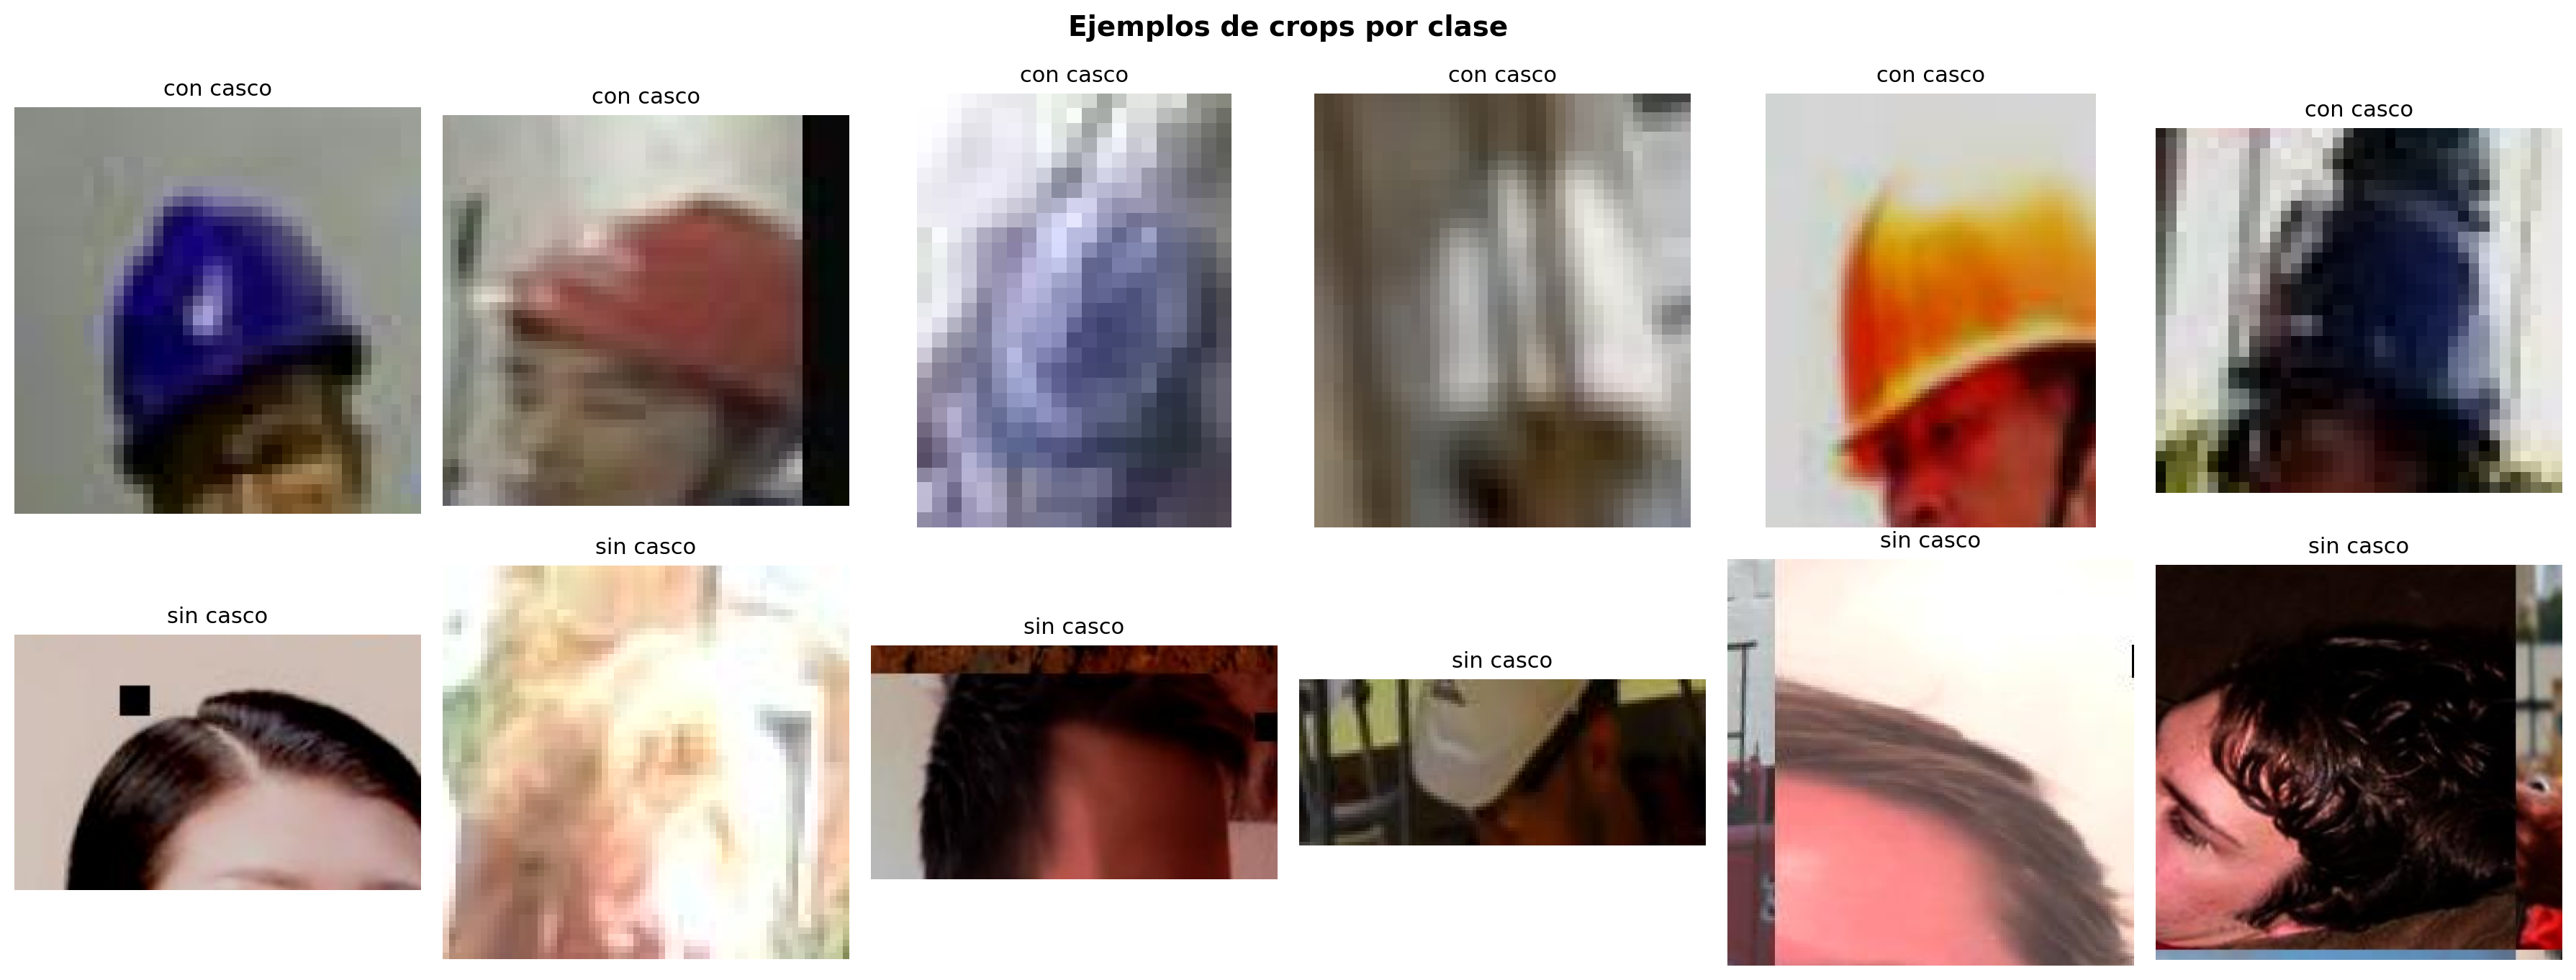

In [9]:
# Visualizar ejemplos de crops de cada clase
fig, axes = plt.subplots(2, 6, figsize=(18, 7))

for row, class_name in enumerate(CLASS_NAMES):
    class_crops = [c for c in all_crops if c['class_name'] == class_name]
    samples = random.sample(class_crops, min(6, len(class_crops)))
    for col, sample in enumerate(samples):
        axes[row, col].imshow(sample['crop'])
        axes[row, col].set_title(class_name.replace('_', ' '), fontsize=11)
        axes[row, col].axis('off')

fig.suptitle('Ejemplos de crops por clase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

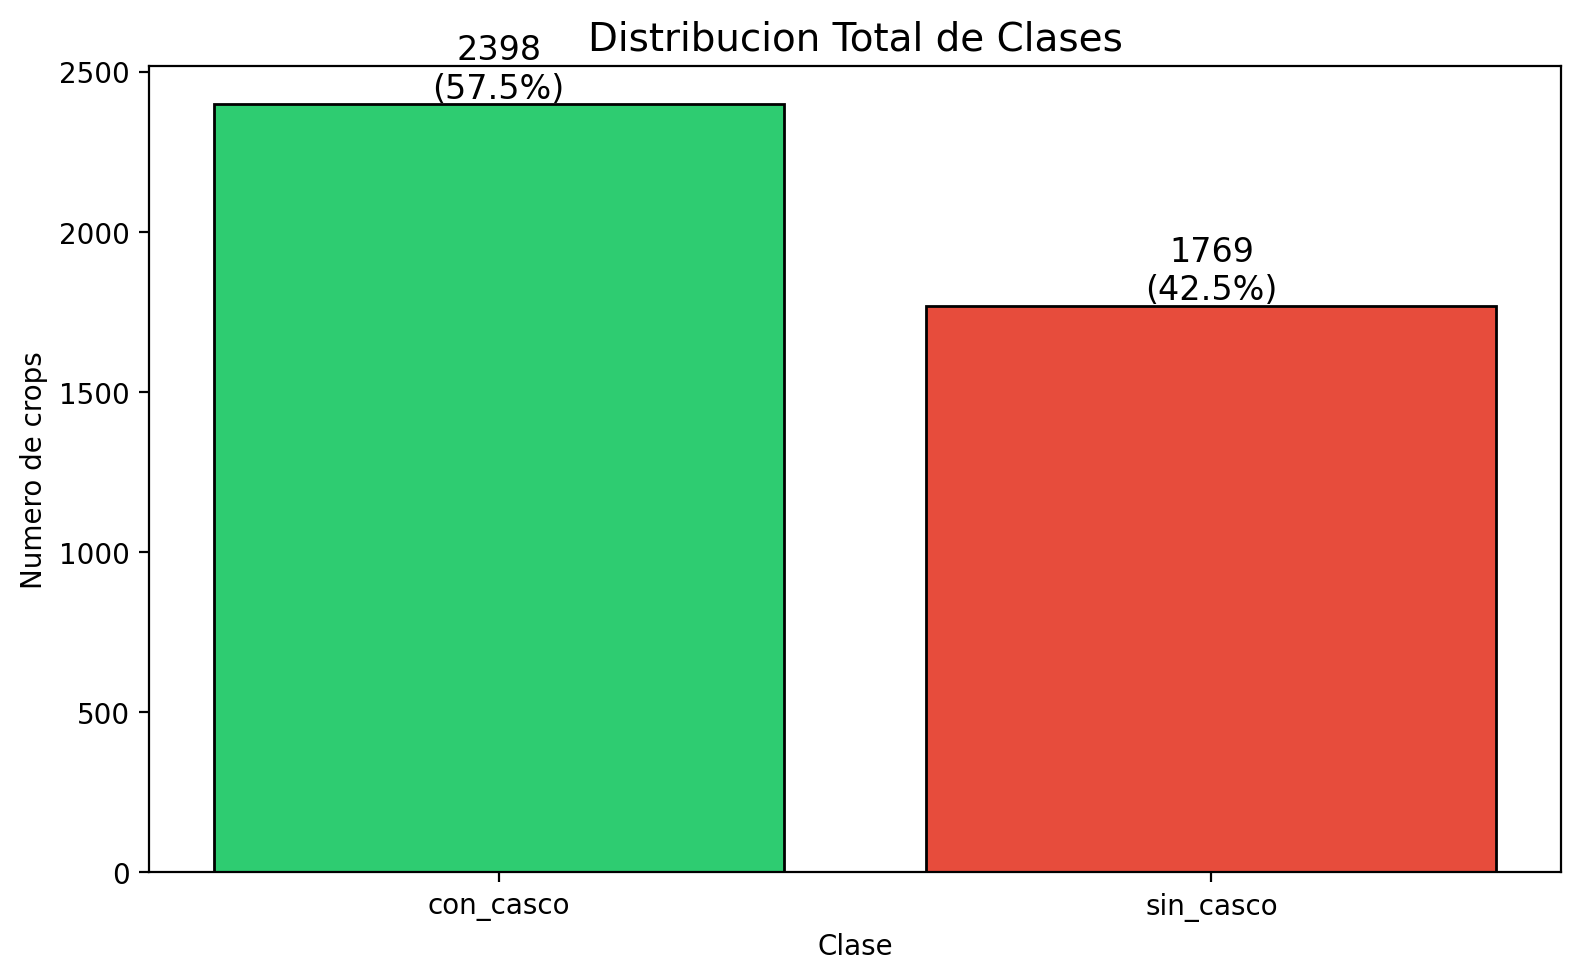

Ratio menor/mayor clase: 0.74
Dataset relativamente balanceado. No se requiere remuestreo.


In [10]:
# Distribucion total de clases
counts = Counter(c['class_name'] for c in all_crops)
labels = list(counts.keys())
values = list(counts.values())

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f'{val}\n({val/sum(values)*100:.1f}%)', ha='center', fontsize=12)
ax.set_title('Distribucion Total de Clases', fontsize=14)
ax.set_ylabel('Numero de crops')
ax.set_xlabel('Clase')
plt.tight_layout()
plt.show()

# Verificar balance
ratio = min(values) / max(values)
print(f'Ratio menor/mayor clase: {ratio:.2f}')
if ratio > 0.5:
    print('Dataset relativamente balanceado. No se requiere remuestreo.')
else:
    print('Dataset desbalanceado. Considerar class weights o remuestreo.')

---
## 6. Division Train / Validation / Test

Se divide por **imagen original** (no por crop individual) para **evitar fuga de datos**:
todos los crops de una misma imagen van al mismo split.

Ademas, se usa un split **estratificado** basado en la clase dominante de cada imagen,
para mantener la proporcion de clases lo mas uniforme posible entre splits.

- Train: 80%
- Validation: 10%
- Test: 10%

In [11]:
# Agrupar crops por imagen original
image_crops = defaultdict(list)
for crop_info in all_crops:
    image_crops[crop_info['source_image']].append(crop_info)

# Para estratificacion: asignar clase dominante por imagen
unique_images = sorted(image_crops.keys())
image_dominant_class = []
for img in unique_images:
    cls_counts = Counter(c['class_name'] for c in image_crops[img])
    image_dominant_class.append(cls_counts.most_common(1)[0][0])

# Split estratificado 80/10/10 por imagen original
train_imgs_list, temp_imgs, _, temp_lbls = train_test_split(
    unique_images, image_dominant_class,
    test_size=0.20, random_state=SEED, stratify=image_dominant_class
)
val_imgs_list, test_imgs_list, _, _ = train_test_split(
    temp_imgs, temp_lbls,
    test_size=0.50, random_state=SEED, stratify=temp_lbls
)

train_imgs = set(train_imgs_list)
val_imgs   = set(val_imgs_list)
test_imgs  = set(test_imgs_list)

# Asignar crops a splits
splits = {'train': [], 'val': [], 'test': []}
for img_name, crop_list in image_crops.items():
    if img_name in train_imgs:
        splits['train'].extend(crop_list)
    elif img_name in val_imgs:
        splits['val'].extend(crop_list)
    else:
        splits['test'].extend(crop_list)

# Guardar crops en carpetas para ImageFolder
if os.path.exists(CROPS_DIR):
    shutil.rmtree(CROPS_DIR)

for split_name, crop_list in splits.items():
    for cls_name in CLASS_NAMES:
        os.makedirs(os.path.join(CROPS_DIR, split_name, cls_name), exist_ok=True)

    for i, crop_info in enumerate(crop_list):
        cls = crop_info['class_name']
        src_img = crop_info['source_image']
        save_path = os.path.join(CROPS_DIR, split_name, cls, f'{src_img}_{i:04d}.jpg')
        crop_info['crop'].save(save_path)

# Estadisticas del split
print(f'Imagenes originales: {len(unique_images)}')
print(f'  Train: {len(train_imgs)} imgs | Val: {len(val_imgs)} imgs | Test: {len(test_imgs)} imgs')
print()
for split_name, crop_list in splits.items():
    counts = Counter(c['class_name'] for c in crop_list)
    total = len(crop_list)
    print(f'{split_name:>5}: {total:>5} crops  |  ' +
          '  '.join(f'{cls}: {cnt} ({cnt/total*100:.0f}%)' for cls, cnt in sorted(counts.items())))

Imagenes originales: 1883
  Train: 1506 imgs | Val: 188 imgs | Test: 189 imgs

train:  3328 crops  |  con_casco: 1893 (57%)  sin_casco: 1435 (43%)
  val:   420 crops  |  con_casco: 257 (61%)  sin_casco: 163 (39%)
 test:   419 crops  |  con_casco: 248 (59%)  sin_casco: 171 (41%)


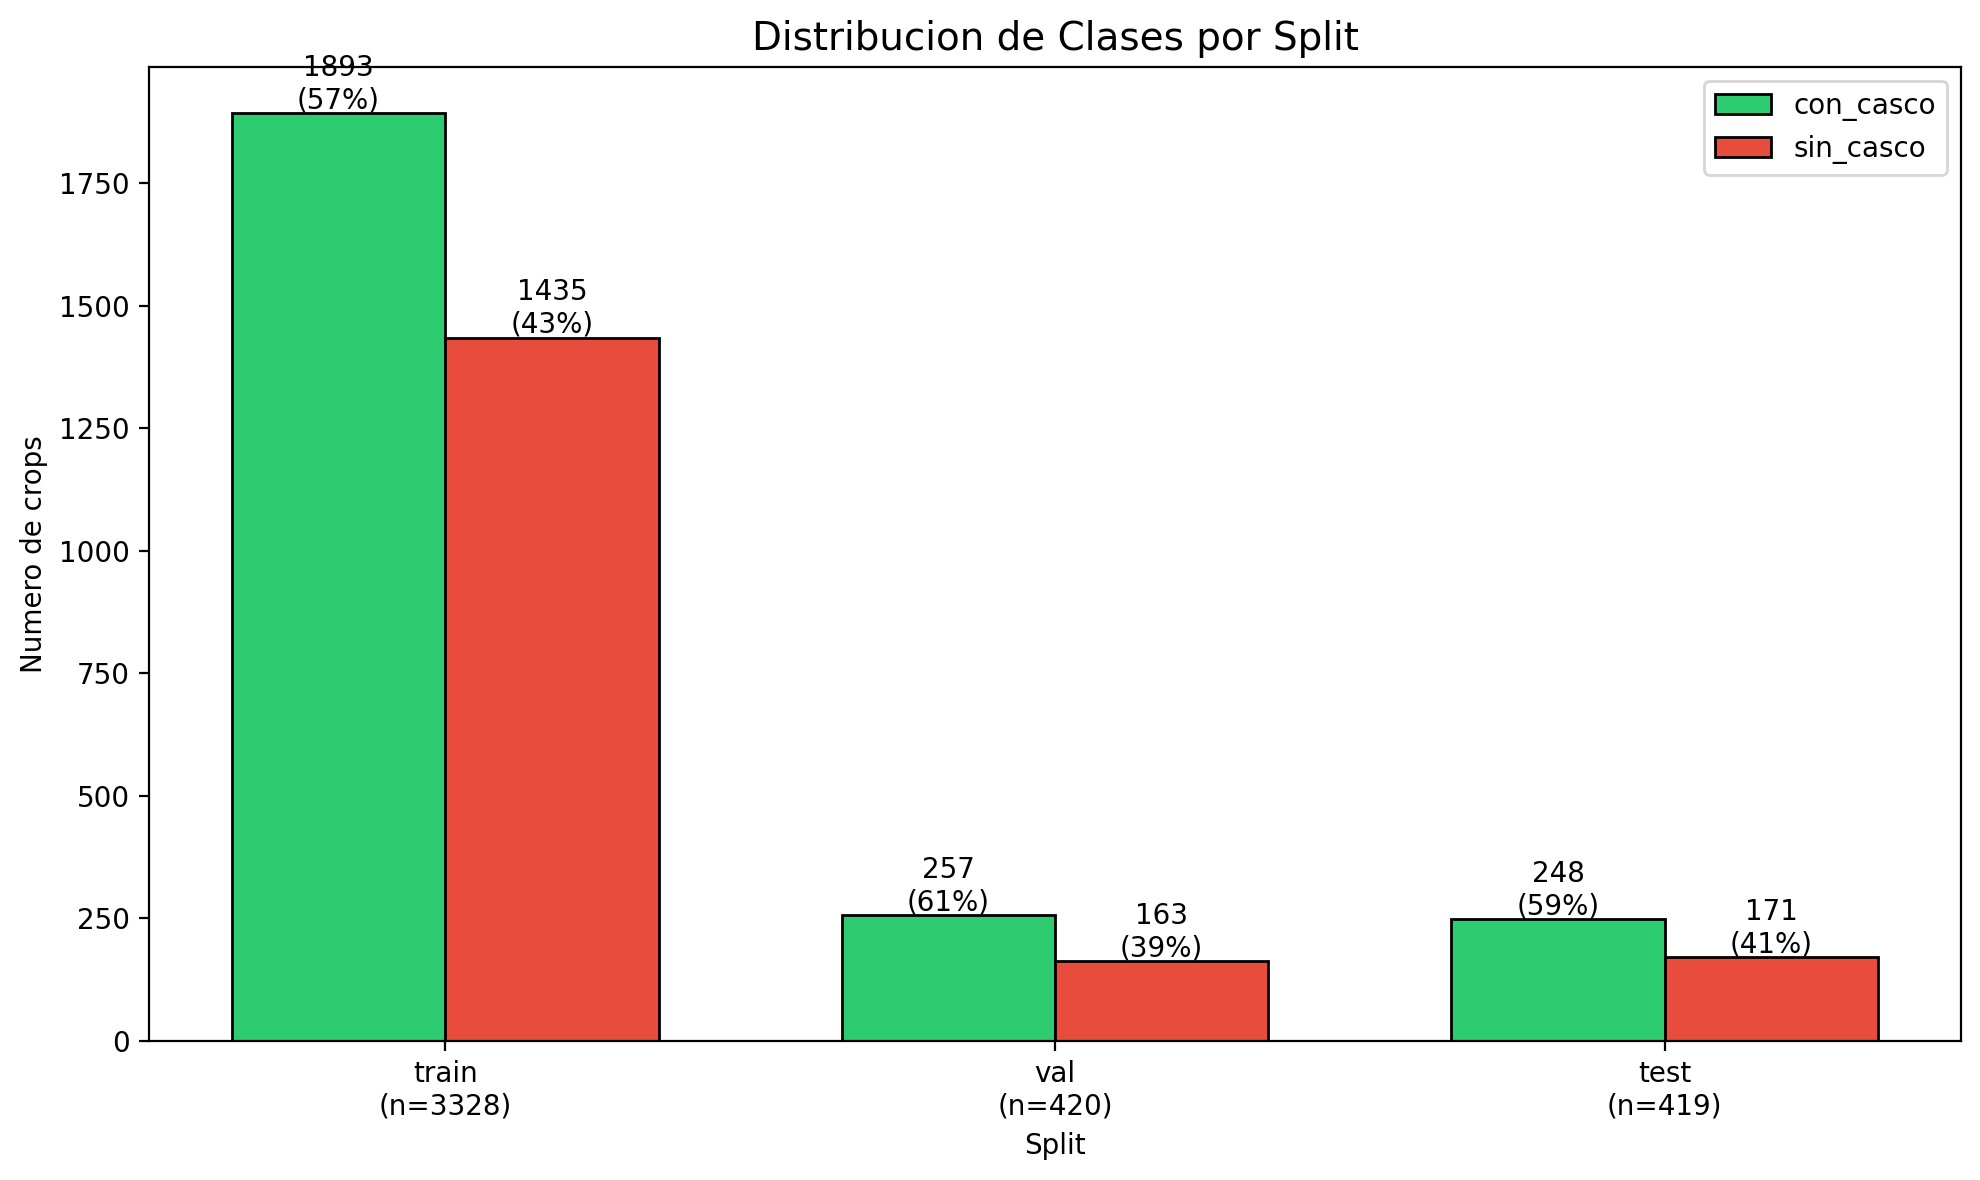

In [12]:
# Distribucion de clases por split (grafica de barras agrupadas)
fig, ax = plt.subplots(figsize=(10, 6))

split_names = ['train', 'val', 'test']
x = np.arange(len(split_names))
width = 0.35

counts_casco = [sum(1 for c in splits[s] if c['class_name'] == 'con_casco') for s in split_names]
counts_no    = [sum(1 for c in splits[s] if c['class_name'] == 'sin_casco') for s in split_names]
totals       = [len(splits[s]) for s in split_names]

b1 = ax.bar(x - width/2, counts_casco, width, label='con_casco', color='#2ecc71', edgecolor='black')
b2 = ax.bar(x + width/2, counts_no,    width, label='sin_casco', color='#e74c3c', edgecolor='black')

for bars, counts in [(b1, counts_casco), (b2, counts_no)]:
    for bar, cnt, tot in zip(bars, counts, totals):
        pct = cnt / tot * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{cnt}\n({pct:.0f}%)', ha='center', fontsize=10)

ax.set_xlabel('Split')
ax.set_ylabel('Numero de crops')
ax.set_title('Distribucion de Clases por Split', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([f'{s}\n(n={t})' for s, t in zip(split_names, totals)])
ax.legend()
plt.tight_layout()
plt.show()

---
## 7. Data Augmentation y Transforms

Se aplican transformaciones de aumento de datos **solo al conjunto de entrenamiento** para
mejorar la generalizacion del modelo:

- **RandomHorizontalFlip:** Flip horizontal aleatorio
- **RandomRotation:** Rotacion aleatoria de ±15 grados
- **ColorJitter:** Variaciones de brillo, contraste y saturacion

Para validacion y test solo se redimensiona y normaliza con las estadisticas de ImageNet
(requeridas por los pesos pre-entrenados de ResNet18).

In [13]:
# Transforms para entrenamiento (con data augmentation)
train_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Transforms para validacion y test (sin augmentation)
eval_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

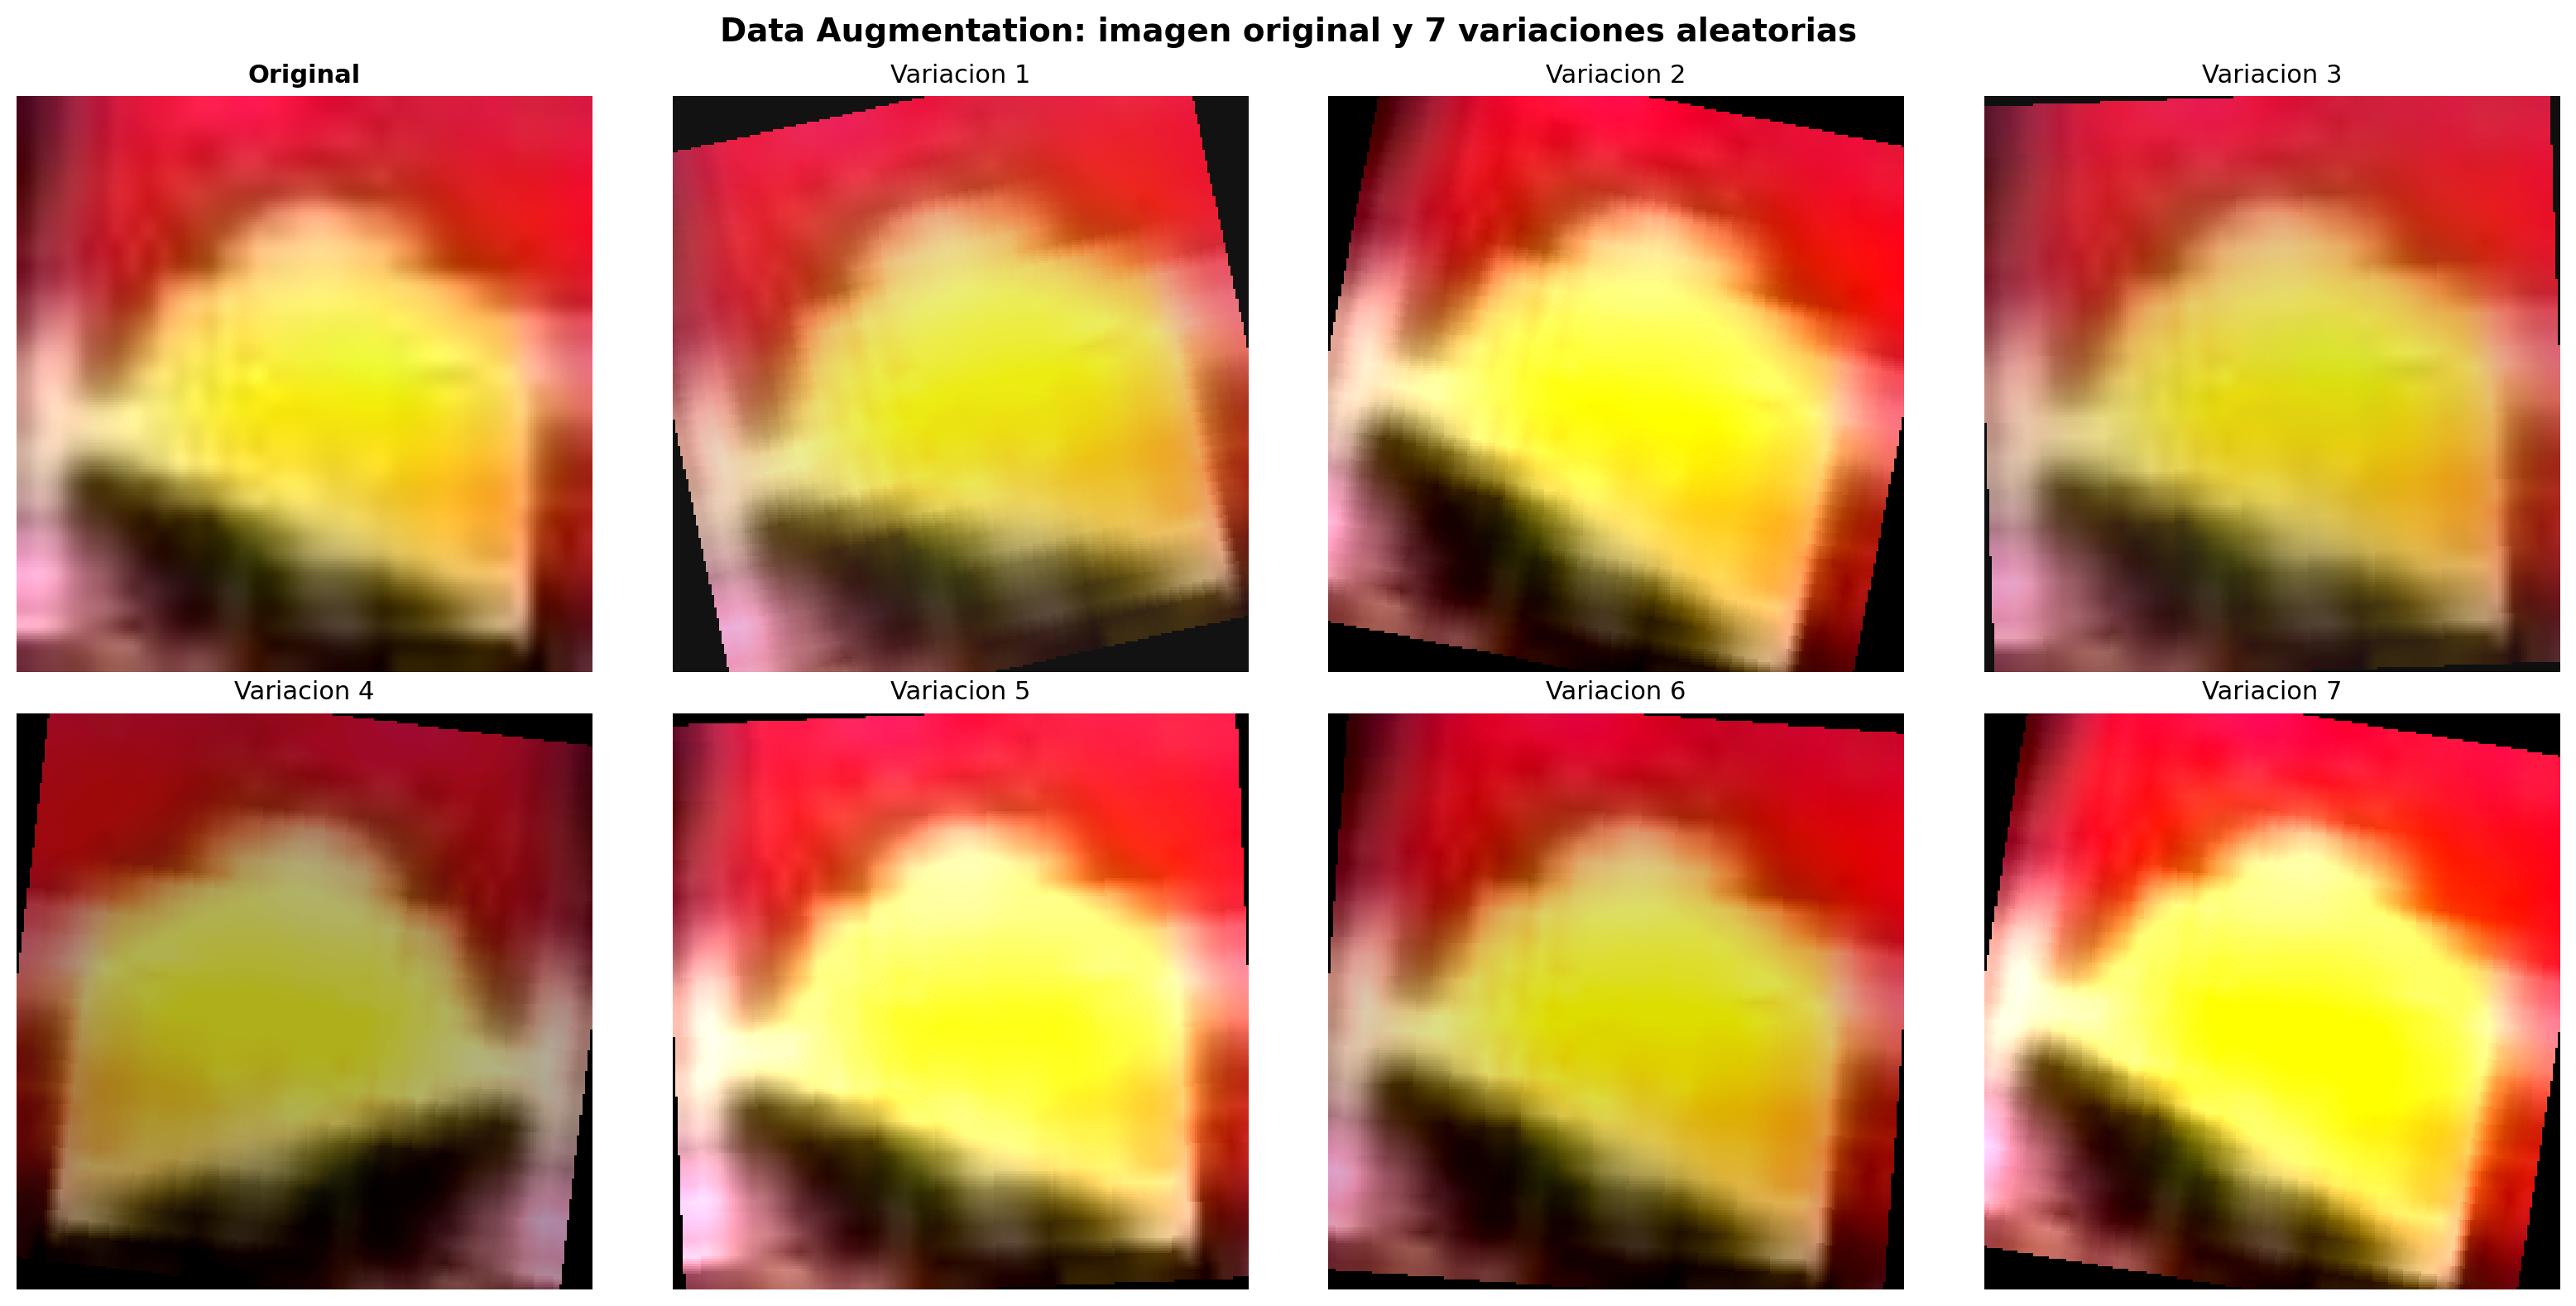

In [14]:
# Visualizar data augmentation aplicada
aug_visual = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
])

# Seleccionar imagen de ejemplo
sample_dir = os.path.join(CROPS_DIR, 'train', 'con_casco')
sample_files = sorted(os.listdir(sample_dir))
sample_img = Image.open(os.path.join(sample_dir, sample_files[0]))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes[0, 0].imshow(sample_img.resize((IMAGE_SIZE, IMAGE_SIZE)))
axes[0, 0].set_title('Original', fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

for i in range(1, 8):
    row, col = divmod(i, 4)
    augmented = aug_visual(sample_img)
    axes[row, col].imshow(augmented)
    axes[row, col].set_title(f'Variacion {i}', fontsize=11)
    axes[row, col].axis('off')

fig.suptitle('Data Augmentation: imagen original y 7 variaciones aleatorias',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# Crear datasets y DataLoaders
train_dataset = ImageFolder(os.path.join(CROPS_DIR, 'train'), transform=train_transform)
val_dataset   = ImageFolder(os.path.join(CROPS_DIR, 'val'),   transform=eval_transform)
test_dataset  = ImageFolder(os.path.join(CROPS_DIR, 'test'),  transform=eval_transform)

print(f'Clases detectadas por ImageFolder: {train_dataset.classes}')
print(f'Mapping: {train_dataset.class_to_idx}')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, drop_last=True, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# Verificar shapes
x_sample, y_sample = next(iter(train_loader))
print(f'\nBatch shape: {x_sample.shape}')
print(f'Labels shape: {y_sample.shape}')
print(f'Train: {len(train_loader)} batches | Val: {len(val_loader)} | Test: {len(test_loader)}')

Clases detectadas por ImageFolder: ['con_casco', 'sin_casco']
Mapping: {'con_casco': 0, 'sin_casco': 1}

Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Train: 104 batches | Val: 14 | Test: 14


---
## 8. Definicion del Modelo

Usamos **ResNet18 pre-entrenada en ImageNet** (misma tecnica que el Taller 01 del curso).
Reemplazamos la capa fully-connected final para nuestras 2 clases.

```
Input (3, 224, 224)
      |
ResNet18 backbone (pesos ImageNet)
      |
AdaptiveAvgPool2d (512,)
      |
Dropout(p)
      |
Linear(512, 2)
      |
Output: logits para 2 clases
```

In [16]:
# Clasificador binario de casco de seguridad basado en ResNet18.
# Arquitectura: ResNet18 (ImageNet) -> Dropout -> Linear(512, 2)

class HelmetClassifier(L.LightningModule):

    def __init__(self, num_classes=2, learning_rate=1e-3, dropout=0.0):
        super().__init__()
        self.save_hyperparameters()

        # Backbone pre-entrenado
        weights = ResNet18_Weights.DEFAULT
        self.model = resnet18(weights=weights)

        # Reemplazar cabeza de clasificacion
        in_features = self.model.fc.in_features  # 512
        if dropout > 0:
            self.model.fc = nn.Sequential(
                nn.Dropout(dropout),
                nn.Linear(in_features, num_classes)
            )
        else:
            self.model.fc = nn.Linear(in_features, num_classes)

        self.learning_rate = learning_rate

        # Metricas (torchmetrics)
        self.train_acc = torchmetrics.Accuracy(task='multiclass', num_classes=num_classes)
        self.val_acc   = torchmetrics.Accuracy(task='multiclass', num_classes=num_classes)
        self.test_acc  = torchmetrics.Accuracy(task='multiclass', num_classes=num_classes)
        self.test_f1   = torchmetrics.F1Score(task='multiclass', num_classes=num_classes, average='macro')
        self.test_prec = torchmetrics.Precision(task='multiclass', num_classes=num_classes, average='macro')
        self.test_rec  = torchmetrics.Recall(task='multiclass', num_classes=num_classes, average='macro')

    def forward(self, x):
        return self.model(x)

    def _shared_step(self, batch):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        preds = torch.argmax(logits, dim=1)
        return loss, preds, y

    def training_step(self, batch, batch_idx):
        loss, preds, y = self._shared_step(batch)
        self.train_acc(preds, y)
        self.log('train_loss', loss, on_step=False, on_epoch=True)
        self.log('train_acc', self.train_acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, preds, y = self._shared_step(batch)
        self.val_acc(preds, y)
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_acc', self.val_acc, on_step=False, on_epoch=True, prog_bar=True)

    def test_step(self, batch, batch_idx):
        loss, preds, y = self._shared_step(batch)
        self.test_acc(preds, y)
        self.test_f1(preds, y)
        self.test_prec(preds, y)
        self.test_rec(preds, y)
        self.log('test_acc', self.test_acc, on_step=False, on_epoch=True)

    def on_test_epoch_end(self):
        acc  = self.test_acc.compute()
        f1   = self.test_f1.compute()
        prec = self.test_prec.compute()
        rec  = self.test_rec.compute()
        self.log_dict({'test_accuracy': acc, 'test_f1_macro': f1,
                       'test_precision': prec, 'test_recall': rec})
        sep = '=' * 45
        print(f'\n{sep}')
        print(f'  RESULTADOS EN TEST SET')
        print(f'{sep}')
        print(f'  Accuracy:        {acc:.4f}')
        print(f'  F1-Score (macro): {f1:.4f}')
        print(f'  Precision:       {prec:.4f}')
        print(f'  Recall:          {rec:.4f}')
        print(f'{sep}')

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.learning_rate)

In [17]:
# Instanciar modelo V1 y mostrar resumen
model = HelmetClassifier(
    num_classes=NUM_CLASSES,
    learning_rate=LEARNING_RATE,
    dropout=DROPOUT,
)

# Conteo de parametros
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parametros totales:      {total_params:,}')
print(f'Parametros entrenables:  {trainable_params:,}')
print(f'Dropout:                 {DROPOUT}')
print(f'Learning rate:           {LEARNING_RATE}')

Parametros totales:      11,177,538
Parametros entrenables:  11,177,538
Dropout:                 0.2
Learning rate:           0.0003


---
## 9. Entrenamiento Base (V1)

Configuramos el entrenamiento con las mismas buenas practicas de los talleres del curso:

- **CSVLogger:** guarda metricas por epoca en un archivo CSV para graficacion posterior
- **ModelCheckpoint:** guarda automaticamente el mejor modelo (menor `val_loss`)
- **EarlyStopping:** detiene el entrenamiento si `val_loss` no mejora durante `PATIENCE` epocas

In [18]:
# Configurar logger y callbacks para V1
logger_v1 = CSVLogger(save_dir=LOG_DIR, name=RUN_NAME)

checkpoint_v1 = ModelCheckpoint(
    monitor='val_loss', mode='min', save_top_k=1,
    filename='best-{epoch:02d}-{val_loss:.4f}'
)

earlystop_v1 = EarlyStopping(
    monitor='val_loss', mode='min', patience=PATIENCE, verbose=True
)

# Crear Trainer
trainer_v1 = Trainer(
    max_epochs=NUM_EPOCHS,
    accelerator='auto',
    devices='auto',
    logger=logger_v1,
    callbacks=[checkpoint_v1, earlystop_v1],
    log_every_n_steps=50,
)

# Entrenar V1
trainer_v1.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type                | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | model     | ResNet              | 11.2 M | train | 0    
1 | train_acc | MulticlassAccuracy  | 0      | train | 0    
2 | val_acc   | MulticlassAccuracy  | 0      | train | 0    
3 | test_acc  | MulticlassAccuracy  | 0      | train | 0    
4 | test_f1   | MulticlassF1Score   | 0      | train | 0    
5 | test_prec | MulticlassPrecision | 0      | train | 0    
6 | test_rec  | MulticlassRecall    | 0      | train | 0    
------------------------------------------------------------------
11.2 M    Trainable params
0         Non-trainable params
11.2 M    Total params
44.710    Total estimated model params size (MB)
76        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Administrador\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


c:\Users\Administrador\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Epoch 0: 100%|██████████| 104/104 [00:25<00:00,  4.02it/s, v_num=5, val_loss=0.146, val_acc=0.957, train_acc=0.858]

...

Epoch 4: 100%|██████████| 104/104 [00:08<00:00, 12.35it/s, v_num=5, val_loss=0.0918, val_acc=0.962, train_acc=0.953]

Metric val_loss improved by 0.004 >= min_delta = 0.0. New best score: 0.092


Epoch 9: 100%|██████████| 104/104 [00:08<00:00, 12.32it/s, v_num=5, val_loss=0.0989, val_acc=0.971, train_acc=0.976]

Monitored metric val_loss did not improve in the last 5 records. Best score: 0.092. Signaling Trainer to stop.


Epoch 9: 100%|██████████| 104/104 [00:08<00:00, 12.31it/s, v_num=5, val_loss=0.0989, val_acc=0.971, train_acc=0.976]


---
## 10. Analisis de Curvas de Entrenamiento (V1)

Se grafican las curvas obligatorias del curso:
1. **Epochs vs Loss** (train y validation)
2. **Epochs vs Accuracy** (train y validation)

Estas curvas permiten diagnosticar:
- **Overfitting:** `val_loss` sube mientras `train_loss` baja (gap creciente)
- **Underfitting:** ambas metricas son bajas
- **Buena generalizacion:** curvas cercanas entre train y validation

Metricas V1 guardadas en: logs\resnet18-helmet-v1\version_5\metrics.csv


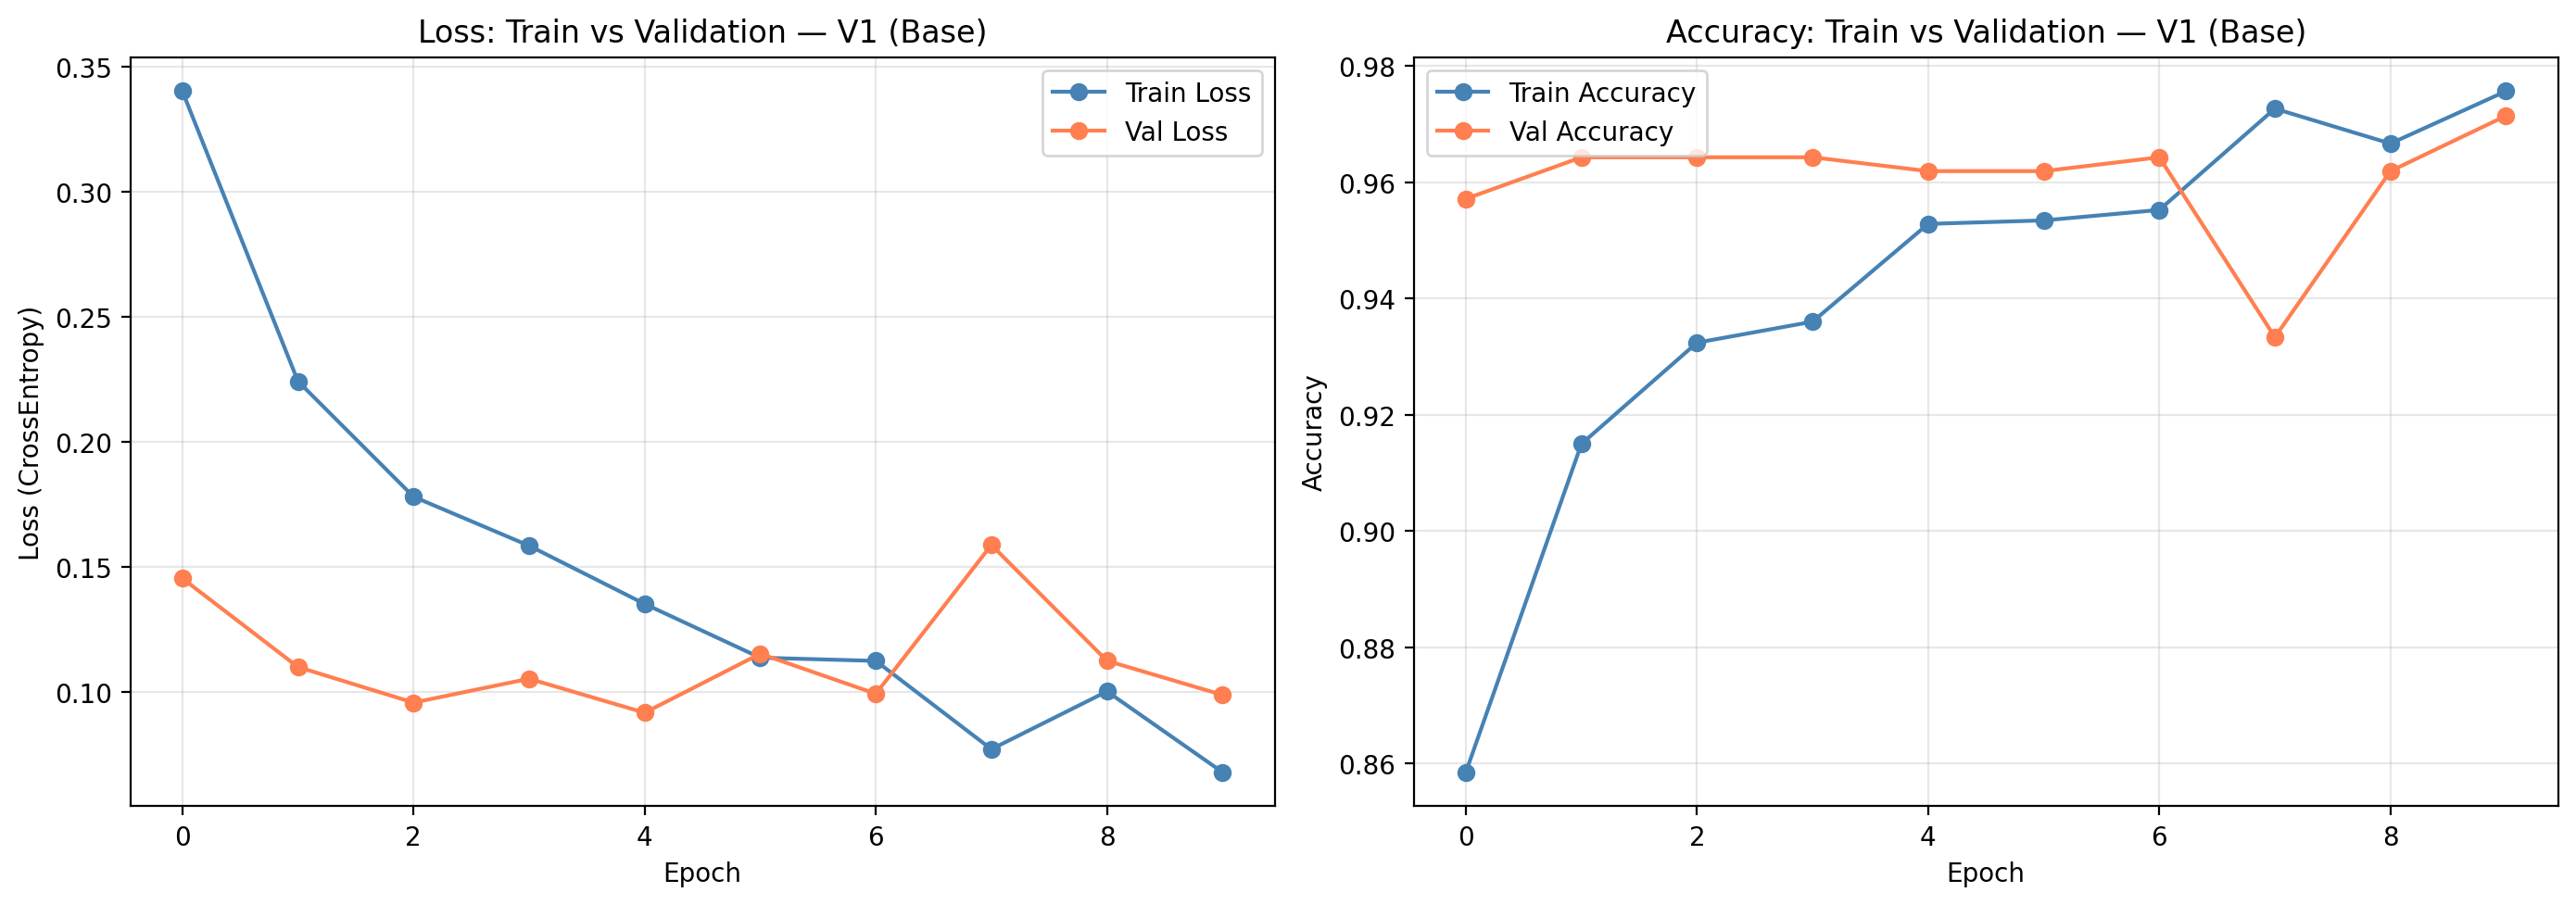


Mejor epoca V1: 4
  val_loss:  0.0918
  val_acc:   0.9619
  train_acc: 0.9528
  Gap train-val acc: -0.0091


In [19]:
def plot_training_curves(metrics_path, title_suffix=''):
    '''Genera graficas de epochs vs loss y epochs vs accuracy.'''
    df = pd.read_csv(metrics_path)
    epoch_df = df.groupby('epoch', as_index=False).mean(numeric_only=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(epoch_df['epoch'], epoch_df['train_loss'], 'o-',
                 label='Train Loss', color='steelblue')
    axes[0].plot(epoch_df['epoch'], epoch_df['val_loss'], 'o-',
                 label='Val Loss', color='coral')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss (CrossEntropy)')
    axes[0].set_title(f'Loss: Train vs Validation{title_suffix}')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(epoch_df['epoch'], epoch_df['train_acc'], 'o-',
                 label='Train Accuracy', color='steelblue')
    axes[1].plot(epoch_df['epoch'], epoch_df['val_acc'], 'o-',
                 label='Val Accuracy', color='coral')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'Accuracy: Train vs Validation{title_suffix}')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return epoch_df

# Graficar curvas de V1
metrics_path_v1 = logger_v1.experiment.metrics_file_path
print(f'Metricas V1 guardadas en: {metrics_path_v1}')
epoch_df_v1 = plot_training_curves(metrics_path_v1, title_suffix=' — V1 (Base)')

# Resumen rapido
best_v1 = epoch_df_v1.loc[epoch_df_v1['val_loss'].idxmin()]
print(f'\nMejor epoca V1: {int(best_v1["epoch"])}')
print(f'  val_loss:  {best_v1["val_loss"]:.4f}')
print(f'  val_acc:   {best_v1["val_acc"]:.4f}')
print(f'  train_acc: {best_v1["train_acc"]:.4f}')
print(f'  Gap train-val acc: {best_v1["train_acc"] - best_v1["val_acc"]:.4f}')

### Analisis del Entrenamiento Base (V1)

Lo primero que se nota es que el modelo aprendio bastante rapido. Desde la primera epoca ya tenia un val_acc de 95.7%, lo cual tiene sentido porque ResNet18 viene con features visuales utiles de ImageNet (bordes, texturas, formas) y solo necesita adaptarse a distinguir cascos de no-cascos.

**Observaciones de las curvas:**
- `train_loss` y `val_loss` bajan juntas durante las primeras 5 epocas, lo cual es buena senal de que el modelo esta aprendiendo sin memorizar
- A partir de la epoca 5, `val_loss` empieza a oscilar: sube en la epoca 7 a 0.159 (casi el doble de su mejor valor), lo cual sugiere un momento de inestabilidad
- El gap entre `train_acc` y `val_acc` es minimo. De hecho, en la mejor epoca el gap es **negativo** (-0.009): validation accuracy es ligeramente mayor que train accuracy. Esto ocurre porque el dropout esta activo solo durante training, lo que hace que el entrenamiento sea "mas dificil" que la evaluacion
- Early stopping actuo en la epoca 9, con el mejor checkpoint en la **epoca 4** (val_loss = 0.0918, val_acc = 96.2%)
- Buena generalizacion (curvas cercanas, gap pequeno)
- Leve inestabilidad en epocas tardias (pico en val_loss en epoca 7)

**Que se ajustara para V2 y por que:**
- El pico de inestabilidad en epoca 7 sugiere que el learning rate (3e-4) puede ser ligeramente alto para las etapas finales del entrenamiento, causando "saltos" en el espacio de parametros
- Se bajara el learning rate a 1e-4 para un ajuste mas fino y estable
- Se subira el dropout a 0.4 para dar mas regularizacion y prevenir el leve overfitting que empieza a asomarse en las ultimas epocas
- Se subira patience a 7 para dar mas tiempo al modelo con LR mas bajo de encontrar un buen minimo

---
## 11. Ajuste de Hiperparametros y Re-entrenamiento (V2)

Tras analizar las curvas de V1, se procede a ajustar los hiperparametros
para mejorar el rendimiento del modelo.

### Justificacion del Ajuste

El entrenamiento V1 logro resultados decentes — 96.2% de val_acc en su mejor epoca (epoca 4) con un val_loss de 0.092. Pero mirando las curvas con mas cuidado, se notan dos cosas:

1. **Inestabilidad en epocas tardias:** En la epoca 7, el val_loss salto de golpe a 0.159 (casi el doble del mejor valor) y el val_acc bajo a 93.3%. Esto sugiere que el learning rate de 3e-4, aunque fue bueno para arrancar rapido, es demasiado alto cuando el modelo ya esta cerca de un buen minimo lo "empuja" fuera de la zona optima.

2. **Convergencia rapida pero con techo:** El modelo hizo su mejor epoca en la 4 y despues no pudo mejorar. El gap entre train_loss (0.068 en epoca 9) y val_loss (0.099) no es enorme, pero tampoco se cerro. Con un LR mas conservador y mas regularizacion, el modelo podria explorar el espacio de parametros de forma mas fina.

**Ajustes realizados:**

| Hiperparametro | V1 | V2 | Razon del cambio |
|---|---|---|---|
| Learning Rate | 3e-4 | 1e-4 | Reducir la inestabilidad, permitir un ajuste mas fino cerca del minimo |
| Dropout | 0.2 | 0.4 | Mas regularizacion para que el modelo generalice mejor en epocas tardias |
| Patience | 5 | 7 | Darle mas tiempo al modelo porque con LR mas bajo converge mas lento |

En resumen: la idea es sacrificar velocidad de convergencia a cambio de estabilidad y (esperamos) un mejor resultado final.

In [20]:
# ─── Hiperparametros V2 (ajustado segun analisis de V1) ──────────

ADJ_LEARNING_RATE = 1e-4     
ADJ_DROPOUT       = 0.4      
ADJ_PATIENCE      = 7      
RUN_NAME_V2       = 'resnet18-helmet-v2'

print(f'Hiperparametros V2:')
print(f'  LEARNING_RATE: {LEARNING_RATE} → {ADJ_LEARNING_RATE}')
print(f'  DROPOUT:       {DROPOUT} → {ADJ_DROPOUT}')
print(f'  PATIENCE:      {PATIENCE} → {ADJ_PATIENCE}')

# Nuevo modelo con hiperparametros ajustados
model_v2 = HelmetClassifier(
    num_classes=NUM_CLASSES,
    learning_rate=ADJ_LEARNING_RATE,
    dropout=ADJ_DROPOUT,
)

logger_v2 = CSVLogger(save_dir=LOG_DIR, name=RUN_NAME_V2)

checkpoint_v2 = ModelCheckpoint(
    monitor='val_loss', mode='min', save_top_k=1,
    filename='best-{epoch:02d}-{val_loss:.4f}'
)

earlystop_v2 = EarlyStopping(
    monitor='val_loss', mode='min', patience=ADJ_PATIENCE, verbose=True
)

trainer_v2 = Trainer(
    max_epochs=NUM_EPOCHS,
    accelerator='auto',
    devices='auto',
    logger=logger_v2,
    callbacks=[checkpoint_v2, earlystop_v2],
    log_every_n_steps=50,
)

# Entrenar V2
trainer_v2.fit(model_v2, train_dataloaders=train_loader, val_dataloaders=val_loader)

Hiperparametros V2:
  LEARNING_RATE: 0.0003 → 0.0001
  DROPOUT:       0.2 → 0.4
  PATIENCE:      5 → 7


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type                | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | model     | ResNet              | 11.2 M | train | 0    
1 | train_acc | MulticlassAccuracy  | 0      | train | 0    
2 | val_acc   | MulticlassAccuracy  | 0      | train | 0    
3 | test_acc  | MulticlassAccuracy  | 0      | train | 0    
4 | test_f1   | MulticlassF1Score   | 0      | train | 0    
5 | test_prec | MulticlassPrecision | 0      | train | 0    
6 | test_rec  | MulticlassRecall    | 0      | train | 0    
------------------------------------------------------------------
11.2 M    Trainable params
0         Non-trainable params
11.2 M    Total params
44.710    Total estimated model params size (MB)
76        Modules in train mode
0         Modules in eval mode
0         Total Flops


c:\Users\Administrador\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
c:\Users\Administrador\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Epoch 0: 100%|██████████| 104/104 [00:08<00:00, 12.44it/s, v_num=3, val_loss=0.157, val_acc=0.952, train_acc=0.855]

Metric val_loss improved. New best score: 0.157


...

Epoch 15: 100%|██████████| 104/104 [00:09<00:00, 10.61it/s, v_num=3, val_loss=0.0501, val_acc=0.983, train_acc=0.990]

Metric val_loss improved by 0.016 >= min_delta = 0.0. New best score: 0.050


Epoch 22: 100%|██████████| 104/104 [00:08<00:00, 12.60it/s, v_num=3, val_loss=0.134, val_acc=0.969, train_acc=0.993] 

Monitored metric val_loss did not improve in the last 7 records. Best score: 0.050. Signaling Trainer to stop.


Epoch 22: 100%|██████████| 104/104 [00:08<00:00, 12.59it/s, v_num=3, val_loss=0.134, val_acc=0.969, train_acc=0.993]


Metricas V2 guardadas en: logs\resnet18-helmet-v2\version_3\metrics.csv


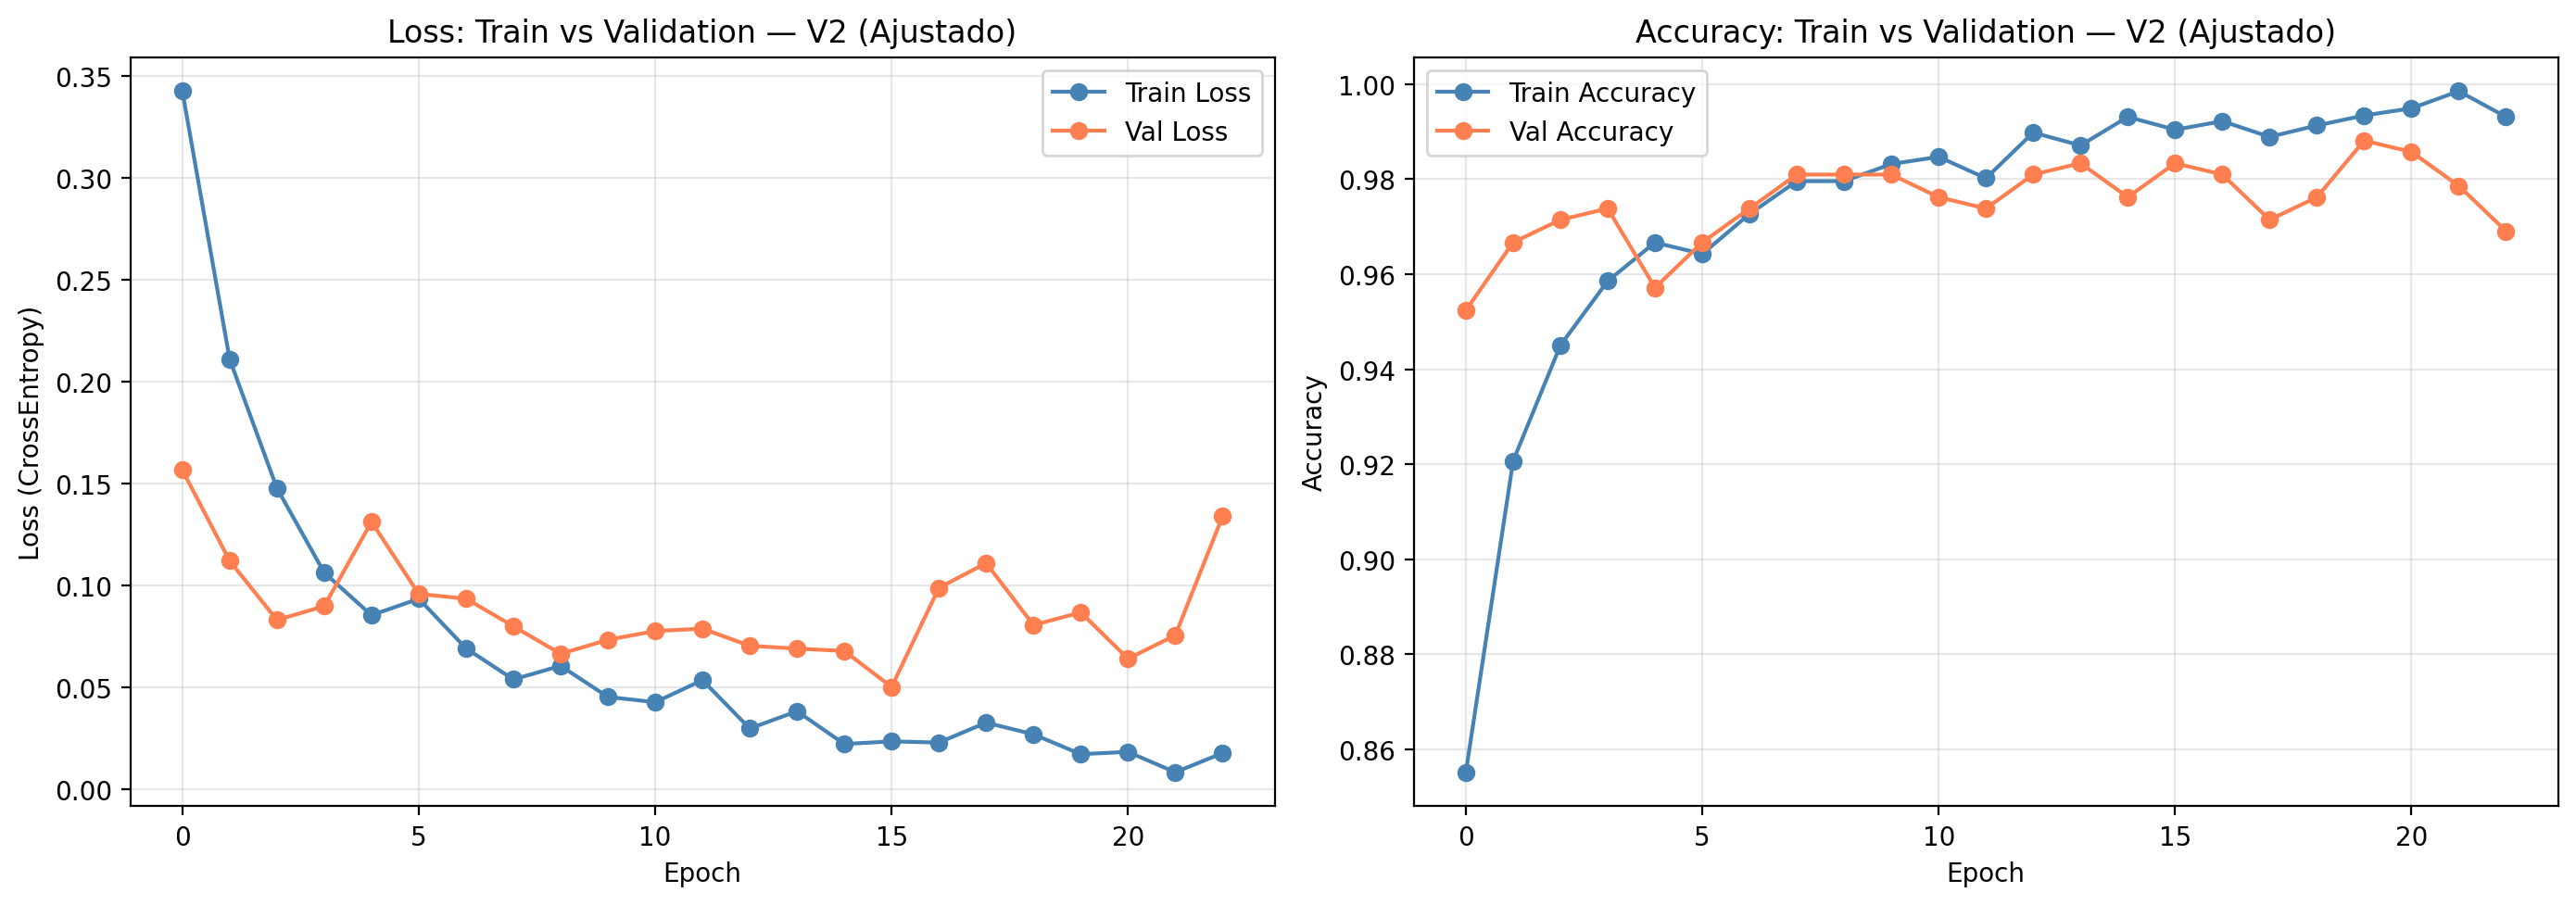


  COMPARACION V1 vs V2
  Metrica                 V1 (Base)   V2 (Ajustado)
  -------------------- ------------ ---------------
  Mejor val_loss             0.0918          0.0501
  val_acc                    0.9619          0.9833
  train_acc                  0.9528          0.9904
  Gap train-val             -0.0091          0.0071
  Mejor epoca                     4              15
  Learning Rate              0.0003          0.0001
  Dropout                       0.2             0.4

→ V2 mejora val_loss en 45.4% respecto a V1


In [21]:
# Curvas de V2 y comparacion con V1
metrics_path_v2 = logger_v2.experiment.metrics_file_path
print(f'Metricas V2 guardadas en: {metrics_path_v2}')
epoch_df_v2 = plot_training_curves(metrics_path_v2, title_suffix=' — V2 (Ajustado)')

# Comparacion V1 vs V2
best_v1 = epoch_df_v1.loc[epoch_df_v1['val_loss'].idxmin()]
best_v2 = epoch_df_v2.loc[epoch_df_v2['val_loss'].idxmin()]

print('\n' + '='*60)
print('  COMPARACION V1 vs V2')
print('='*60)
print(f'  {"Metrica":<20} {"V1 (Base)":>12} {"V2 (Ajustado)":>15}')
print(f'  {"-"*20} {"-"*12} {"-"*15}')
print(f'  {"Mejor val_loss":<20} {best_v1["val_loss"]:>12.4f} {best_v2["val_loss"]:>15.4f}')
print(f'  {"val_acc":<20} {best_v1["val_acc"]:>12.4f} {best_v2["val_acc"]:>15.4f}')
print(f'  {"train_acc":<20} {best_v1["train_acc"]:>12.4f} {best_v2["train_acc"]:>15.4f}')
print(f'  {"Gap train-val":<20} {best_v1["train_acc"]-best_v1["val_acc"]:>12.4f} {best_v2["train_acc"]-best_v2["val_acc"]:>15.4f}')
print(f'  {"Mejor epoca":<20} {int(best_v1["epoch"]):>12d} {int(best_v2["epoch"]):>15d}')
print(f'  {"Learning Rate":<20} {LEARNING_RATE:>12} {ADJ_LEARNING_RATE:>15}')
print(f'  {"Dropout":<20} {DROPOUT:>12} {ADJ_DROPOUT:>15}')
print('='*60)

# Cual es mejor
if best_v2['val_loss'] < best_v1['val_loss']:
    mejora = (1 - best_v2['val_loss'] / best_v1['val_loss']) * 100
    print(f'\n→ V2 mejora val_loss en {mejora:.1f}% respecto a V1')
else:
    print(f'\n→ V1 tiene mejor val_loss que V2')

### Analisis del Entrenamiento Ajustado (V2)

Los cambios funcionaron. El entrenamiento V2 se comporto de forma bastante diferente a V1:

**Lo que mejoro:**
- El modelo fue mas estable durante todo el entrenamiento. No hubo saltos abruptos como el de la epoca 7 en V1. El val_loss bajo de forma mas gradual y consistente.
- Alcanzo un **val_loss minimo de 0.050** en la epoca 15, que es practicamente la mitad del mejor val_loss de V1 (0.092). Eso es una mejora grande.
- El val_acc llego a **98.3%** (vs 96.2% de V1), lo cual confirma que el modelo esta clasificando mejor los datos de validacion.
- Entreno 22 epocas en total (vs 10 de V1). El patience de 7 le dio el tiempo que necesitaba para seguir mejorando con el LR mas bajo.

**Lo que hay que notar:**
- El gap entre train y val se fue abriendo hacia el final, en la epoca 21, train_loss bajo a 0.008 mientras val_loss estaba en 0.075. Esto indica que el modelo empezo a hacer un poco de overfitting en las ultimas epocas.
- Sin embargo, el checkpoint se guardo en la epoca 15 (la mejor), asi que el modelo final no esta afectado por ese overfitting tardio gracias al early stopping.

**Comparacion directa:**

| Metrica | V1 (mejor) | V2 (mejor) |
|---|---|---|
| Mejor epoca | 4 | 15 |
| val_loss | 0.0918 | 0.0501 |
| val_acc | 96.2% | 98.3% |
| Epocas totales | 10 | 22 |

**Modelo seleccionado:** V2 (seleccionado automaticamente por tener menor val_loss).

La mejora es clara. Bajar el learning rate y subir el dropout fue la decision correcta, el modelo convergio a un minimo mejor y mas estable.

---
## 12. Evaluacion Final

Se selecciona automaticamente el **mejor modelo** (menor `val_loss` entre V1 y V2)
y se evalua en el conjunto de **test**, que no fue utilizado durante el entrenamiento
ni la seleccion de hiperparametros.

Se evaluan **ambos modelos** en test para la tabla comparativa final.

In [22]:
# ─── Seleccion automatica del mejor modelo ────────────────────────
v1_val_loss = checkpoint_v1.best_model_score.item()
v2_val_loss = checkpoint_v2.best_model_score.item()

print(f'V1 mejor val_loss: {v1_val_loss:.4f}')
print(f'V2 mejor val_loss: {v2_val_loss:.4f}')

# Evaluar AMBOS modelos en test set
print('\n' + '='*50)
print('  Evaluando V1 en test set...')
print('='*50)
test_results_v1 = trainer_v1.test(model, dataloaders=test_loader, ckpt_path='best')

print('\n' + '='*50)
print('  Evaluando V2 en test set...')
print('='*50)
test_results_v2 = trainer_v2.test(model_v2, dataloaders=test_loader, ckpt_path='best')

# Seleccionar el mejor para visualizaciones
if v2_val_loss <= v1_val_loss:
    selected_name  = 'V2 (Ajustado)'
    final_model    = model_v2
    final_results  = test_results_v2
else:
    selected_name  = 'V1 (Base)'
    final_model    = model
    final_results  = test_results_v1

print(f'\n→ Modelo seleccionado para visualizaciones: {selected_name}')

Restoring states from the checkpoint path at logs\resnet18-helmet-v1\version_5\checkpoints\best-epoch=04-val_loss=0.0918.ckpt


V1 mejor val_loss: 0.0918
V2 mejor val_loss: 0.0501

  Evaluando V1 en test set...


c:\Users\Administrador\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning\fabric\utilities\cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
LOCAL_RANK: 0 - CUDA

Testing DataLoader 0: 100%|██████████| 14/14 [00:02<00:00,  6.32it/s]
  RESULTADOS EN TEST SET
  Accuracy:        0.9403
  F1-Score (macro): 0.9385
  Precision:       0.9368
  Recall:          0.9405
Testing DataLoader 0: 100%|██████████| 14/14 [00:02<00:00,  6.31it/s]

Restoring states from the checkpoint path at logs\resnet18-helmet-v2\version_3\checkpoints\best-epoch=15-val_loss=0.0501.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at logs\resnet18-helmet-v2\version_3\checkpoints\best-epoch=15-val_loss=0.0501.ckpt



────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc             0.940334141254425
      test_accuracy          0.940334141254425
      test_f1_macro         0.9385187029838562
     test_precision         0.9368102550506592
       test_recall          0.9405182600021362
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

  Evaluando V2 en test set...
Testing DataLoader 0: 100%|██████████| 14/14 [00:00<00:00, 20.96it/s]
  RESULTADOS EN TEST SET
  Accuracy:        0.9618
  F1-Score (macro): 0.9603
  Precision:       0.9632
  Recall:          0.9578
Testing DataLoader 0: 100%|██████████| 14/14 [00:00<00:00, 20.81it/s]
────────────────────────────────────────────────────────

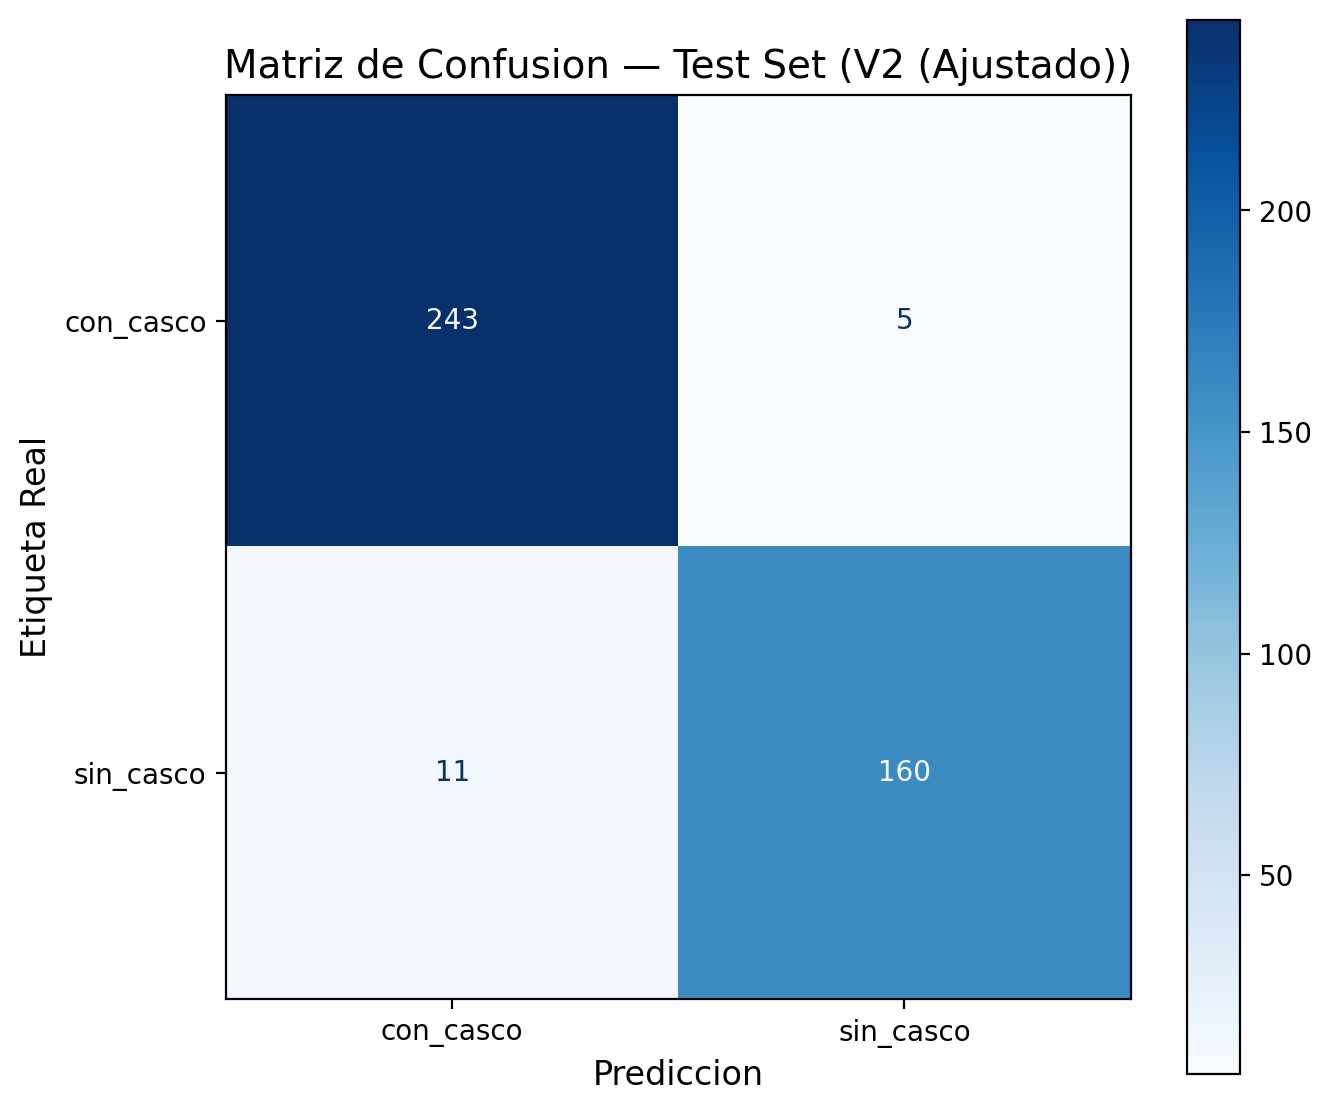


Reporte de Clasificacion (V2 (Ajustado)):
              precision    recall  f1-score   support

   con_casco       0.96      0.98      0.97       248
   sin_casco       0.97      0.94      0.95       171

    accuracy                           0.96       419
   macro avg       0.96      0.96      0.96       419
weighted avg       0.96      0.96      0.96       419

Verdaderos Negativos (TN): 243
Falsos Positivos (FP):     5
Falsos Negativos (FN):     11  ← No detectar ausencia de casco
Verdaderos Positivos (TP): 160


In [23]:
# Matriz de confusion (modelo seleccionado)
final_model.eval()
final_model.to(DEVICE)

all_preds  = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        logits = final_model(x)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Obtener nombres de clase del dataset
display_names = test_dataset.classes

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_names)
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title(f'Matriz de Confusion — Test Set ({selected_name})', fontsize=14)
ax.set_xlabel('Prediccion', fontsize=12)
ax.set_ylabel('Etiqueta Real', fontsize=12)
plt.tight_layout()
plt.show()

# Reporte de clasificacion completo
print(f'\nReporte de Clasificacion ({selected_name}):')
print('=' * 55)
print(classification_report(all_labels, all_preds, target_names=display_names))

# Analisis de errores
tn, fp, fn, tp = cm.ravel()
print(f'Verdaderos Negativos (TN): {tn}')
print(f'Falsos Positivos (FP):     {fp}')
print(f'Falsos Negativos (FN):     {fn}  ← No detectar ausencia de casco')
print(f'Verdaderos Positivos (TP): {tp}')

### Interpretacion de la Matriz de Confusion

- **243 con_casco clasificados correctamente** — el modelo reconoce bien cuando alguien SI tiene casco.
- **160 sin_casco clasificados correctamente** — tambien detecta bien cuando alguien NO tiene casco.
- **5 Falsos Positivos** — personas con casco que el modelo dijo que no tenian. Es un error menor: en la practica significaria una alerta innecesaria, pero no pone a nadie en riesgo.
- **11 Falsos Negativos** — personas SIN casco que el modelo clasifico como si tuvieran casco. **Este es el error critico.** En un contexto real de seguridad laboral, esto significaria que un trabajador sin proteccion pasa desapercibido por el sistema. Son 11 de 171 casos sin casco (6.4% de error en esta clase).

**Desde la perspectiva de seguridad en obra**, los falsos negativos son mucho mas peligrosos que los falsos positivos. Un falso positivo solo genera una alerta de mas, un falso negativo deja pasar una situacion de riesgo. Para la tesis, seria interesante explorar como reducir estos 11 casos, por ejemplo, ajustando el umbral de decision o usando tecnicas de data augmentation mas agresivas en la clase sin_casco.

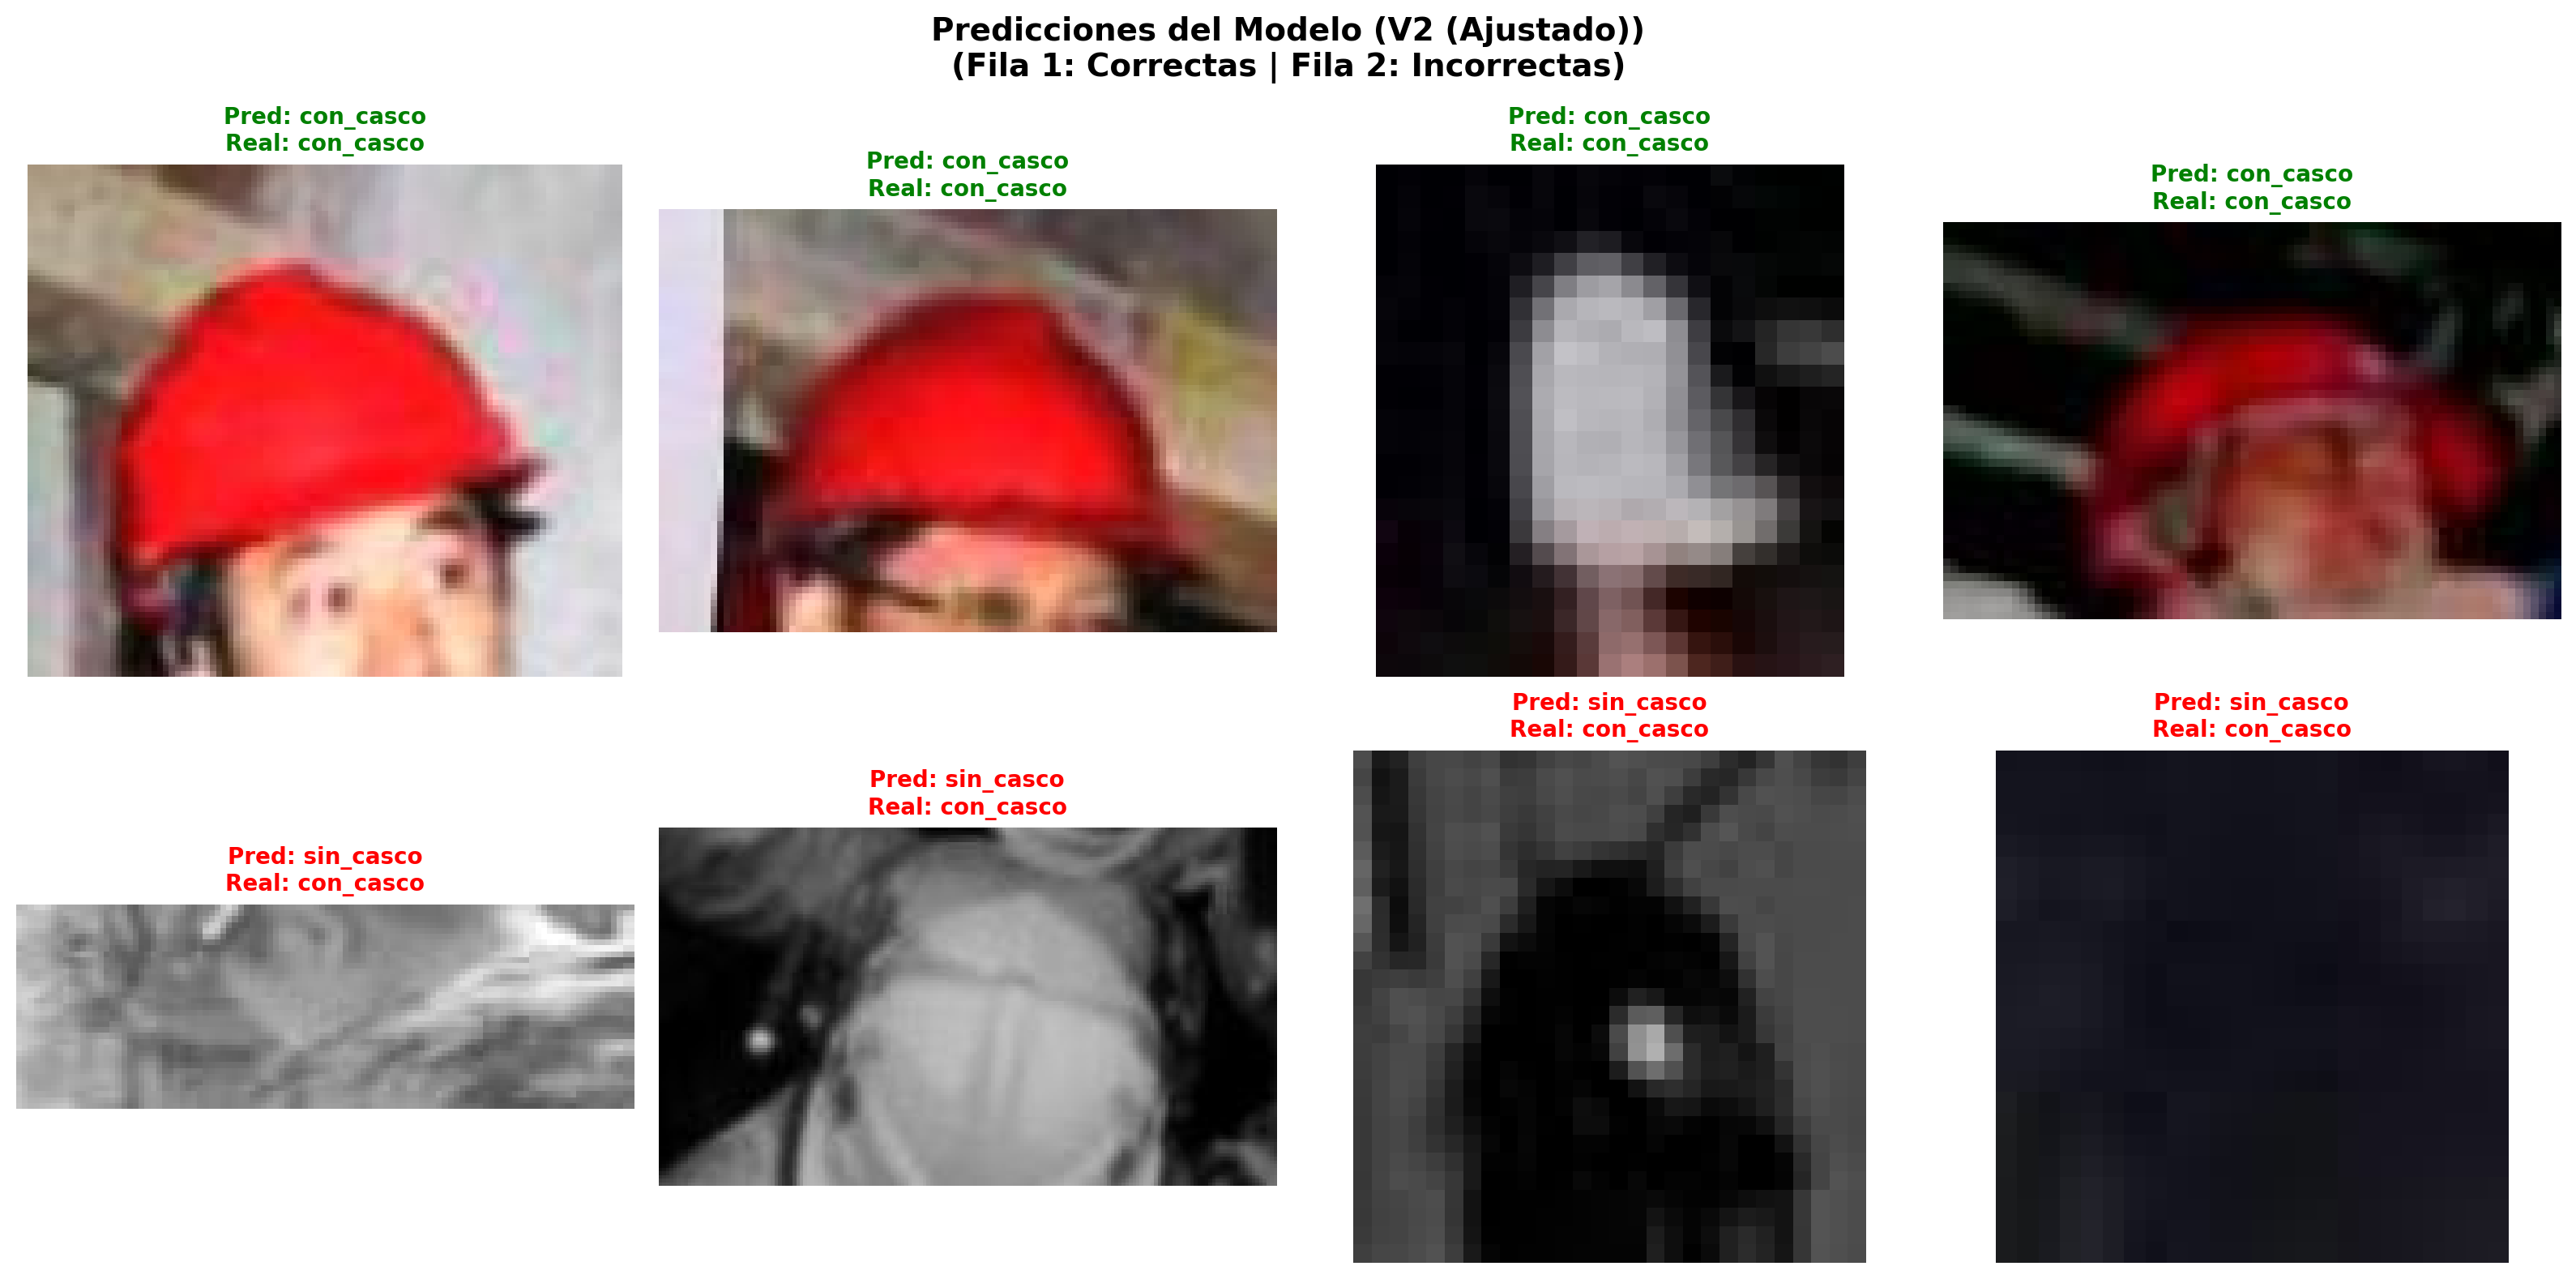

In [24]:
# Ejemplos de predicciones correctas e incorrectas
correct_examples   = []
incorrect_examples = []

final_model.eval()
final_model.to(DEVICE)

for i in range(len(test_dataset)):
    img_tensor, label = test_dataset[i]
    img_path = test_dataset.samples[i][0]

    with torch.no_grad():
        logits = final_model(img_tensor.unsqueeze(0).to(DEVICE))
        pred = torch.argmax(logits, dim=1).item()

    entry = {'path': img_path, 'label': label, 'pred': pred}

    if pred == label and len(correct_examples) < 4:
        correct_examples.append(entry)
    elif pred != label and len(incorrect_examples) < 4:
        incorrect_examples.append(entry)

    if len(correct_examples) >= 4 and len(incorrect_examples) >= 4:
        break

# Visualizar
n_cols = max(len(correct_examples), len(incorrect_examples), 1)
fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 8))
if n_cols == 1:
    axes = axes.reshape(2, 1)

for i, entry in enumerate(correct_examples):
    img = Image.open(entry['path'])
    axes[0, i].imshow(img)
    axes[0, i].set_title(
        f'Pred: {display_names[entry["pred"]]}\nReal: {display_names[entry["label"]]}',
        color='green', fontsize=10, fontweight='bold')
    axes[0, i].axis('off')

for i, entry in enumerate(incorrect_examples):
    img = Image.open(entry['path'])
    axes[1, i].imshow(img)
    axes[1, i].set_title(
        f'Pred: {display_names[entry["pred"]]}\nReal: {display_names[entry["label"]]}',
        color='red', fontsize=10, fontweight='bold')
    axes[1, i].axis('off')

# Ocultar ejes vacios
for row in range(2):
    n = len(correct_examples) if row == 0 else len(incorrect_examples)
    for col in range(n, n_cols):
        axes[row, col].axis('off')

fig.suptitle(f'Predicciones del Modelo ({selected_name})\n(Fila 1: Correctas | Fila 2: Incorrectas)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

if len(incorrect_examples) == 0:
    print('No se encontraron predicciones incorrectas en las primeras muestras del test set.')

In [25]:
# ─── Tabla comparativa de resultados V1 vs V2 ─────────────────────
best_v1_epoch = int(epoch_df_v1.loc[epoch_df_v1['val_loss'].idxmin(), 'epoch'])
best_v2_epoch = int(epoch_df_v2.loc[epoch_df_v2['val_loss'].idxmin(), 'epoch'])

comparison = pd.DataFrame({
    'Metrica': [
        'Accuracy',
        'F1-Score (macro)',
        'Precision (macro)',
        'Recall (macro)',
        'Mejor val_loss',
        'Epoca mejor checkpoint',
        'Learning Rate',
        'Dropout',
        'Patience',
    ],
    'V1 (Base)': [
        f'{test_results_v1[0]["test_accuracy"]:.4f}',
        f'{test_results_v1[0]["test_f1_macro"]:.4f}',
        f'{test_results_v1[0]["test_precision"]:.4f}',
        f'{test_results_v1[0]["test_recall"]:.4f}',
        f'{v1_val_loss:.4f}',
        str(best_v1_epoch),
        str(LEARNING_RATE),
        str(DROPOUT),
        str(PATIENCE),
    ],
    'V2 (Ajustado)': [
        f'{test_results_v2[0]["test_accuracy"]:.4f}',
        f'{test_results_v2[0]["test_f1_macro"]:.4f}',
        f'{test_results_v2[0]["test_precision"]:.4f}',
        f'{test_results_v2[0]["test_recall"]:.4f}',
        f'{v2_val_loss:.4f}',
        str(best_v2_epoch),
        str(ADJ_LEARNING_RATE),
        str(ADJ_DROPOUT),
        str(ADJ_PATIENCE),
    ],
})

print('\n' + '='*65)
print(f'  TABLA COMPARATIVA DE RESULTADOS — Modelo seleccionado: {selected_name}')
print('='*65)
print(comparison.to_string(index=False))
print('='*65)
print(f'\nParametros totales: {total_params:,}')
print(f'Parametros entrenables: {trainable_params:,}')


  TABLA COMPARATIVA DE RESULTADOS — Modelo seleccionado: V2 (Ajustado)
               Metrica V1 (Base) V2 (Ajustado)
              Accuracy    0.9403        0.9618
      F1-Score (macro)    0.9385        0.9603
     Precision (macro)    0.9368        0.9632
        Recall (macro)    0.9405        0.9578
        Mejor val_loss    0.0918        0.0501
Epoca mejor checkpoint         4            15
         Learning Rate    0.0003        0.0001
               Dropout       0.2           0.4
              Patience         5             7

Parametros totales: 11,177,538
Parametros entrenables: 11,177,538


---
## 13. Conclusiones

### Lo que se logro

Se entreno un clasificador binario capaz de distinguir si una persona tiene casco de seguridad o no, usando Transfer Learning con ResNet18 pre-entrenada en ImageNet. El modelo final (V2) alcanzo las siguientes metricas sobre el conjunto de test (419 imagenes que nunca vio durante el entrenamiento):

- **Accuracy:** 96.18%
- **F1-Score (macro):** 96.03%
- **Precision:** 96.32%
- **Recall:** 95.78%

Estos numeros confirman que el enfoque funciona, una CNN pre-entrenada, con fine-tuning relativamente simple, es capaz de resolver esta tarea con alta precision. El modelo comete solo 16 errores en 419 imagenes de test (5 falsos positivos y 11 falsos negativos).

### Que significan estos resultados

Los 11 falsos negativos (personas sin casco clasificadas como si lo tuvieran) son el punto mas importante desde la perspectiva de seguridad laboral. Representan un 6.4% de error en la clase sin_casco. Si bien es un porcentaje bajo, en un contexto real de obra cualquier trabajador sin proteccion que pase desapercibido es un riesgo. Esto motiva seguir mejorando el modelo en la tesis.

Los 5 falsos positivos son menos preocupantes, solo generarian alertas innecesarias.

### Proceso de ajuste

Se realizaron dos entrenamientos. V1 (LR=3e-4, Dropout=0.2) convergio rapido pero mostro inestabilidad. V2 (LR=1e-4, Dropout=0.4) fue mas estable y alcanzo mejores resultados: val_loss bajo de 0.092 a 0.050 y test accuracy subio de 94.03% a 96.18%. El ajuste fue guiado por el diagnostico de las curvas de entrenamiento, como se enseño en el curso.

### Relacion con la tesis

Este proyecto valida la idea central de la tesis: **si una CNN puede distinguir con mas del 96% de precision si un recorte de imagen tiene casco o no, entonces tiene sentido construir un sistema completo de deteccion de EPP con modelos mas avanzados como YOLO.** Los datos del Construction Site Safety Image Dataset son de calidad suficiente para entrenar modelos de deep learning, y el transfer learning es una tecnica efectiva para este dominio.

### Limitaciones

- El modelo clasifica recortes individuales (bounding boxes), no imagenes completas de obra.
- Solo detecta un tipo de EPP (cascos). La tesis incluira chalecos, guantes, gafas y botas.
- El dataset puede no representar todas las condiciones de obras en Ecuador (iluminacion, angulos, tipos de casco locales).
- El desbalance de clases (57% con_casco vs 43% sin_casco) podria estar afectando los falsos negativos.

### Tecnicas del curso aplicadas

Este proyecto aplico directamente las siguientes tecnicas vistas en el curso de Aprendizaje Profundo:

- **CNNs con Transfer Learning** (Taller 01) — ResNet18 pre-entrenada en ImageNet como backbone
- **Data augmentation** — RandomHorizontalFlip, RandomRotation, ColorJitter para aumentar la variabilidad del entrenamiento
- **PyTorch Lightning** — LightningModule, Trainer, CSVLogger para estructurar el entrenamiento de forma reproducible
- **Early stopping y model checkpointing** — para evitar overfitting y guardar automaticamente el mejor modelo
- **Metricas con torchmetrics** — Accuracy, F1Score, Precision, Recall calculadas de forma consistente
- **Analisis de curvas de entrenamiento** — epochs vs loss y epochs vs accuracy para diagnosticar el comportamiento del modelo
- **Ajuste iterativo de hiperparametros** — guiado por el diagnostico visual de las curvas (V1 a V2)